# Between-scanner, within-scanner and between-paradigm variability of FC matrices

In [1]:
library(reticulate)
library(tidyr)
library(MANOVA.RM)
library(irr)
library(effectsize)
use_python("/home/cprovins/miniconda3/envs/pymc_env/bin/python", required = TRUE)

Loading required package: lpSolve



## Load the FC matrices

We load the functional connectivity (FC) matrices using Python code so we can conveniently leverage our custom configuration for PyBIDS. Which scanner was the participant scanned on during the generalization sessions is encoded in the last three digits of the session number (Prisma=060, Vida=034, VidaFit=030). For the investigation of the paradigm influence, we keep only the generalization sessions using the Prisma scanner.

In [2]:
py_run_string('
import re
import pandas as pd
from pathlib import Path
from bids.layout import BIDSLayout, BIDSLayoutIndexer, add_config_paths
from confounds import get_confounds

# Define filtering parameters
metric = "correlation"
atlas_dimension = "64"
fd_threshold = 0.5
fdthresh_str = str(fd_threshold).replace(".", "")

# Define paths
code_path = Path("/data/code/hcph-sops/")
fc_path = Path(f"/data/derivatives/hcph-fc")
dataset_path = Path("/data/datasets/hcph-dataset")
confounds_path = dataset_path / "phenotype" / "mood_env_quest.tsv"

# Initialize the BIDS layout
config_path = code_path / "code/bids/indexer.json"
try:
    add_config_paths(hcph=config_path)
except ValueError as e:
    if "Configuration \'hcph\' already exists" in str(e):
        print("Configuration hcph already exists, skipping add_config_paths.")
    else:
        raise e

_indexer = BIDSLayoutIndexer(
    config_filename=config_path,
    index_metadata=False,
    validate=False,
)

# Define entities common to all files
entities_base = {
    "subject": "001",
    "measure": metric,
    "scale": atlas_dimension,
    "fd_threshold": fdthresh_str,
}
')

Note that if you already computed and saved the ICC in a table, you can directly jump to the section "Visualize the ICC results".

In [ ]:
py_run_string('
layout = BIDSLayout(fc_path, config="hcph", indexer=_indexer, validate=False)

## Load FC matrices for the generalization sessions
entities_base_gen = {
    **entities_base,
    "task": "rest",
}
# Get functional connectivity files
files_gen = layout.get(**entities_base_gen, suffix="connectivity", extension=".tsv", return_type="file")
assert len(files_gen) == 36, f"Expected 36 FC matrices, got {len(files_gen)}"
df_fc = pd.DataFrame({"filename": files_gen, "subject": "001"})

# Retrieve which scanner was used for each session (encoded in the last three digits of the session ID)
df_fc["session"] = df_fc["filename"].apply(lambda x: re.search(r"ses-(\\d+)", x).group(1) if re.search(r"ses-(\\d+)", x) else None)

def extract_scanner(session):
    scanner_codes = {"060": "prisma", "034": "vida", "030": "vidafit"}
    code = session[-3:]
    return scanner_codes.get(code, "unknown")

df_fc["scanner"] = df_fc["session"].apply(extract_scanner)
df_fc["repetition"] = df_fc["session"].str[1:3].astype(int)

## Load confounds
confounds_df = get_confounds(dataset_path, confounds_path, confounds_of_interest=["slept_rest"])
# Keep only the magnitude part of functional scans and first echo
confounds_df = confounds_df[confounds_df["modality"] == "func"]
# Keep only the resting-state scans
confounds_df = confounds_df[confounds_df["task"].isin(["rest", "rsmovie"])]
# Drop columns that are not needed here
confounds_df = confounds_df.drop(columns=["filename", "modality", "task", "day_of_week", "time_of_day"])

# Merge the confounds in
df_fc = pd.merge(
        df_fc, confounds_df, on=["subject", "session"], how="inner"
    )

## Load FC matrices from the reliability sessions
entities_base_rel = {
    **entities_base,
    "task": "rsmovie",
}
files_rel = layout.get(**entities_base_rel, suffix="connectivity", extension=".tsv", return_type="file")
assert len(files_rel) == 36, f"Expected 36 FC matrices, got {len(files_rel)}"
df_rsmovie = pd.DataFrame({"filename": files_rel, "task": "rsmovie", "subject": "001"})
df_rsmovie["session"] = df_rsmovie["filename"].apply(lambda x: re.search(r"ses-(\\d+)", x).group(1) if re.search(r"ses-(\\d+)", x) else None)
df_rsmovie["repetition"] = df_rsmovie.index + 1
# Merge the confounds in
df_rsmovie = pd.merge(df_rsmovie, confounds_df, on=["subject", "session"], how="inner")

# Keep only the session with prisma scanner for investigation of paradigm influence
df_fc_paradigm = df_fc[df_fc["scanner"] == "prisma"]
df_fc_paradigm = df_fc_paradigm.drop(columns=["scanner"])
df_fc_paradigm["task"] = "rest"
assert len(df_fc_paradigm) == 12, f"Expected 12 FC matrices for prisma scanner, got {len(df_fc_paradigm)}"

## Concatenate the two dataframes
df_fc_paradigm = pd.concat([df_fc_paradigm, df_rsmovie], ignore_index=True)
assert len(df_fc_paradigm) == 48, f"Expected 48 FC matrices after concatenation, got {len(df_fc_paradigm)}"
')

In [38]:
## Helper function to load the FC matrices from the file paths
load_fc_matrices <- function(df) {
    # Load all FC matrices and add the upper triangle flattened to the dataframe.
    # Since the FC matrix is symmetric, retaining only the upper triangle is sufficient.
    for (i in seq_len(nrow(df))) {
        tsv_file <- df$filename[i]
        mat <- as.matrix(read.table(tsv_file, header = FALSE, sep = "\t"))
        if (grepl("sparseinversecovariance", tsv_file)) {
            # Negate the precision matrix to get partial correlations
            mat <- -mat
        }
        # Flatten the upper triangle of the matrix (excluding diagonal)
        flat <- mat[upper.tri(mat, diag = FALSE)]
        col_names <- paste0("edge", seq_along(flat))
        # Add values to the dataframe
        for (j in seq_along(flat)) {
            df[i, col_names[j]] <- flat[j]
        }
    }
    # Remove the filename column as it is no longer needed
    df$filename <- NULL
    return(df)
}

In [39]:
# Load the panda DataFrame into R
df_fc <- as.data.frame(py$df_fc)
df_fc <- load_fc_matrices(df_fc)
stopifnot(nrow(df_fc) == 36) #assert statement

df_rsmovie <- as.data.frame(py$df_rsmovie)
df_rsmovie <- load_fc_matrices(df_rsmovie)
stopifnot(nrow(df_rsmovie) == 36)

df_fc_paradigm <- as.data.frame(py$df_fc_paradigm)
df_fc_paradigm <- load_fc_matrices(df_fc_paradigm)
stopifnot(nrow(df_fc_paradigm) == 48)
head(df_fc)

,subject,session,scanner,repetition,acq_time,pe_dir,slept_rest,edge1,edge2,edge3,⋯,edge1882,edge1883,edge1884,edge1885,edge1886,edge1887,edge1888,edge1889,edge1890,edge1891
,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,001,20101060,prisma,1,2024-08-20T21:19:11.542500,AP,Yes,0.2827941,0.3701252,0.5657622,⋯,0.1730595,0.3102559,0.2121344,0.2031167,0.4770941,0.2953542,0.1642162,0.4734638,0.4889089,0.3620068
2,001,20102030,vidafit,1,2024-08-20T22:59:30.355000,RL,No,0.2989734,0.4257047,0.6455861,⋯,0.5119642,0.4776001,0.4571604,0.4440488,0.6165075,0.3442986,0.4719748,0.3867397,0.4178769,0.5189680
3,001,20103034,vida,1,2024-08-21T00:32:54.322500,PA,No,0.5496409,0.6378708,0.6992454,⋯,0.6684356,0.4696130,0.5322509,0.4993899,0.7612367,0.5316175,0.5145998,0.5403605,0.6864804,0.5960710
4,001,20201060,prisma,2,2024-08-21T20:51:59.287500,RL,Yes,0.2171777,0.5192892,0.4158072,⋯,0.4358424,0.4371684,0.2114518,0.3034416,0.4864878,0.3020995,0.4284669,0.3970554,0.5058466,0.4216522
5,001,20202030,vidafit,2,2024-08-21T22:23:23.142500,AP,No,0.5146798,0.4826543,0.6256755,⋯,0.6440360,0.5486310,0.5267422,0.4705275,0.6739694,0.5031739,0.4826841,0.5139879,0.5398819,0.5300936
6,001,20203034,vida,2,2024-08-22T00:04:15.010000,RL,No,0.5096338,0.6318354,0.6954506,⋯,0.6452073,0.5660315,0.5724041,0.4610906,0.6353785,0.5021469,0.5146907,0.4986800,0.5097432,0.6179405


## Intra-class correlation coefficient (ICC) to quantify between-scanner variability

In [40]:
icc_vals <- data.frame(edge = character(), ICC = numeric(), stringsAsFactors = FALSE)

# Iterate over all edges
col_names <- colnames(df_fc)
#Remove non-iqms column names
edge_keys <- col_names[grepl("^edge", col_names)]
if (any(!grepl("^edge", edge_keys))) {
    stop("All elements in edge_keys must contain 'edge'")
}
for (edge in edge_keys) {
    # Keep only the edge and session columns
    df_icc <- df_fc[, c( "scanner", edge)]
    df_icc <- pivot_wider(df_icc, names_from = scanner, values_from = edge, values_fn = list)
    df_icc <- unnest(df_icc, cols = c(prisma, vida, vidafit))
    # Compute ICC(2,1) for this edge
    icc_val <- icc(df_icc, model = "twoway", type = "agreement", unit = "single")$value
    icc_vals <- rbind(icc_vals, data.frame(edge = edge, ICC = icc_val))
}
head(df_icc)
head(icc_vals)

prisma,vidafit,vida
<dbl>,<dbl>,<dbl>
0.3620068,0.5189680,0.5960710
0.4216522,0.5300936,0.6179405
0.3304195,0.5457828,0.5529241
0.5405864,0.3387351,0.3527906
0.5553758,0.6012507,0.3855313
0.5059431,0.5073618,0.4913253


,edge,ICC
,<chr>,<dbl>
1,edge1,0.05878540
2,edge2,0.07420592
3,edge3,-0.02879484
4,edge4,-0.34783099
5,edge5,-0.07901565
6,edge6,-0.10314388


Mean ICC across edges: -0.05502567 
Median ICC across edges: -0.07998961 


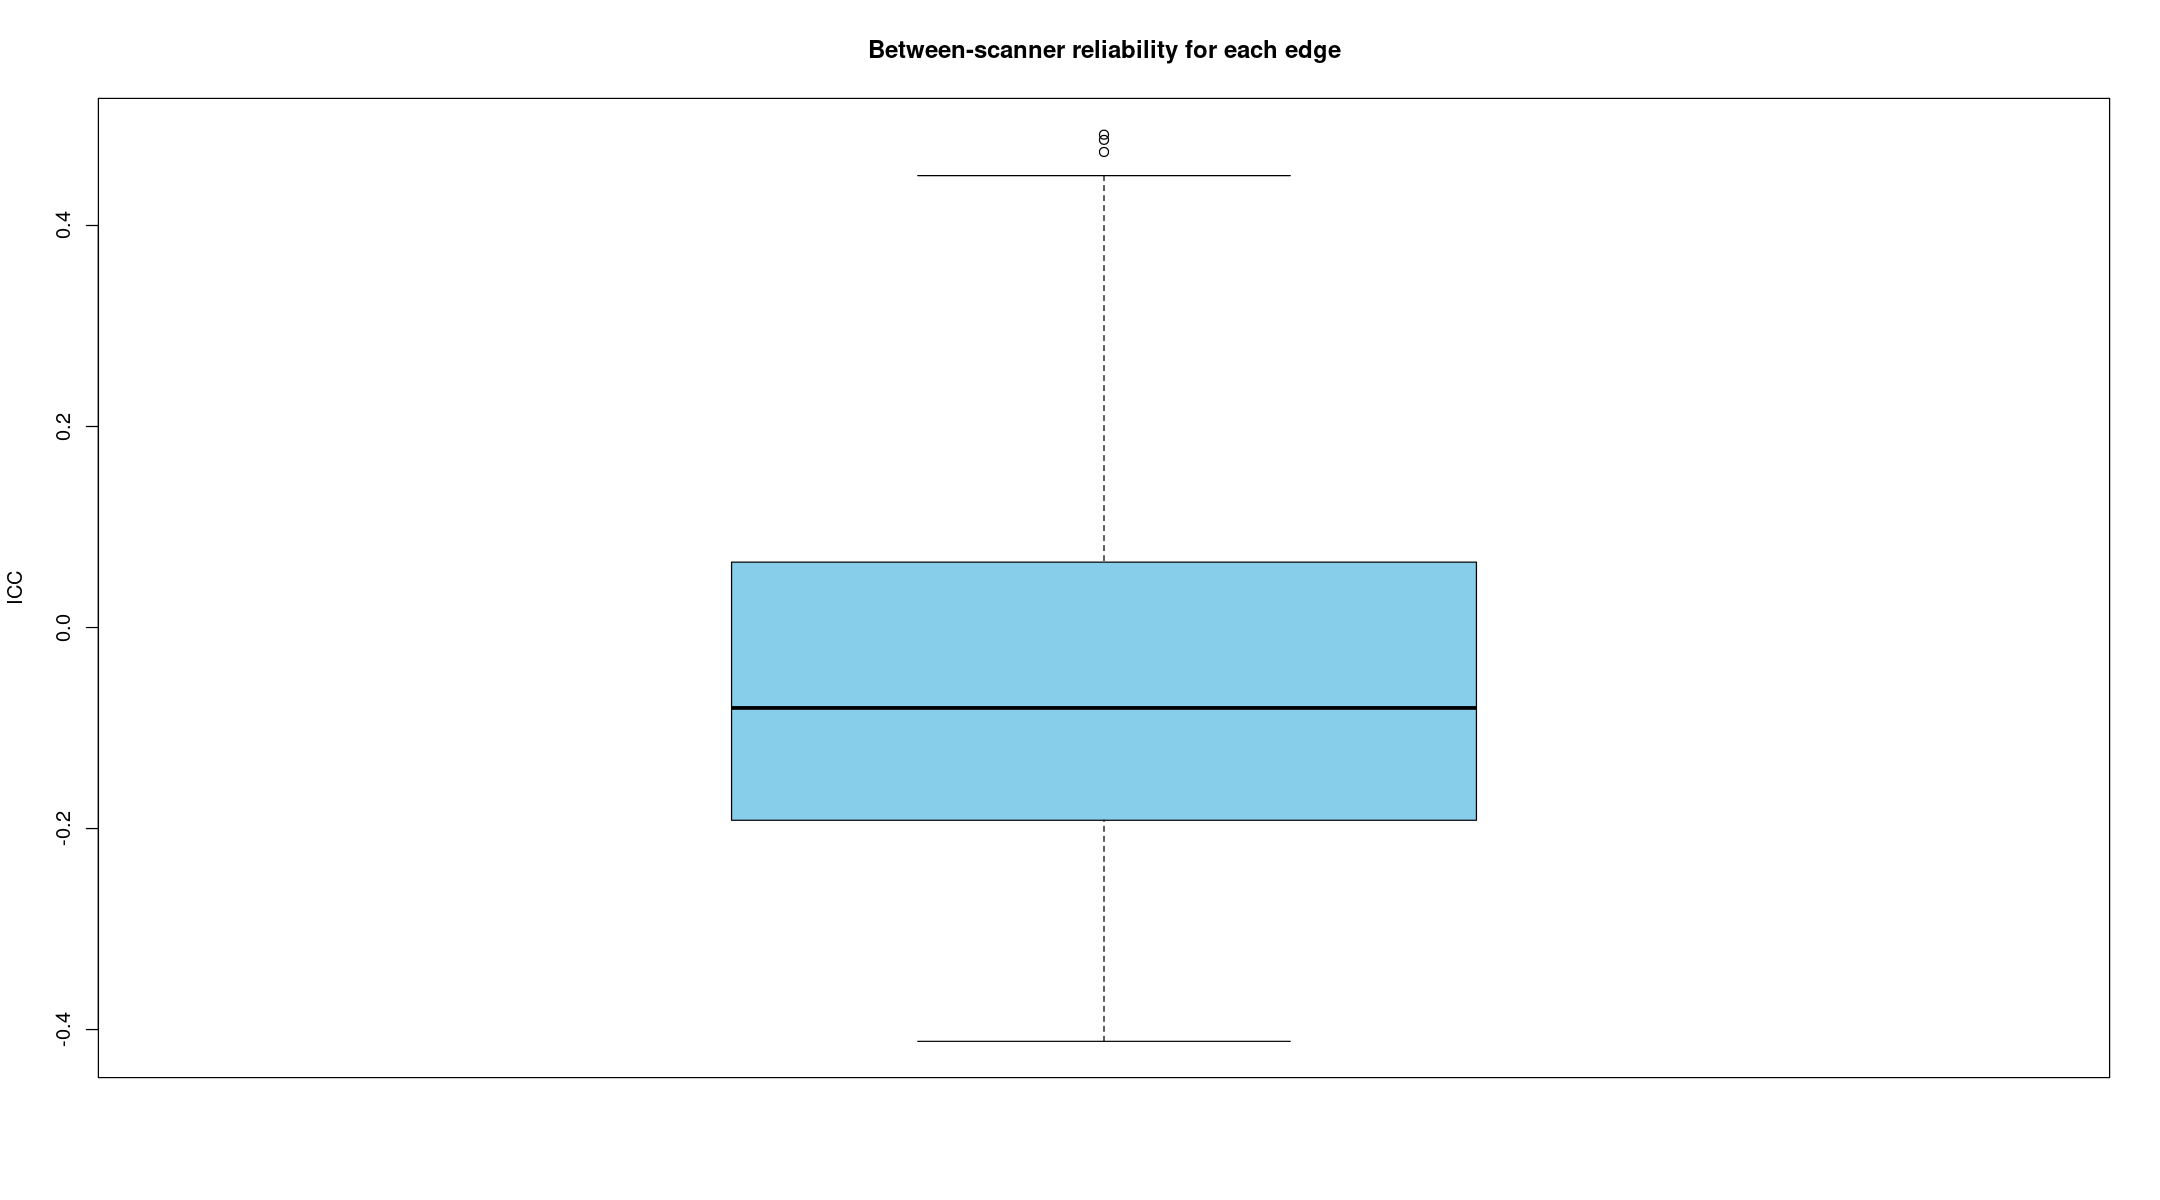

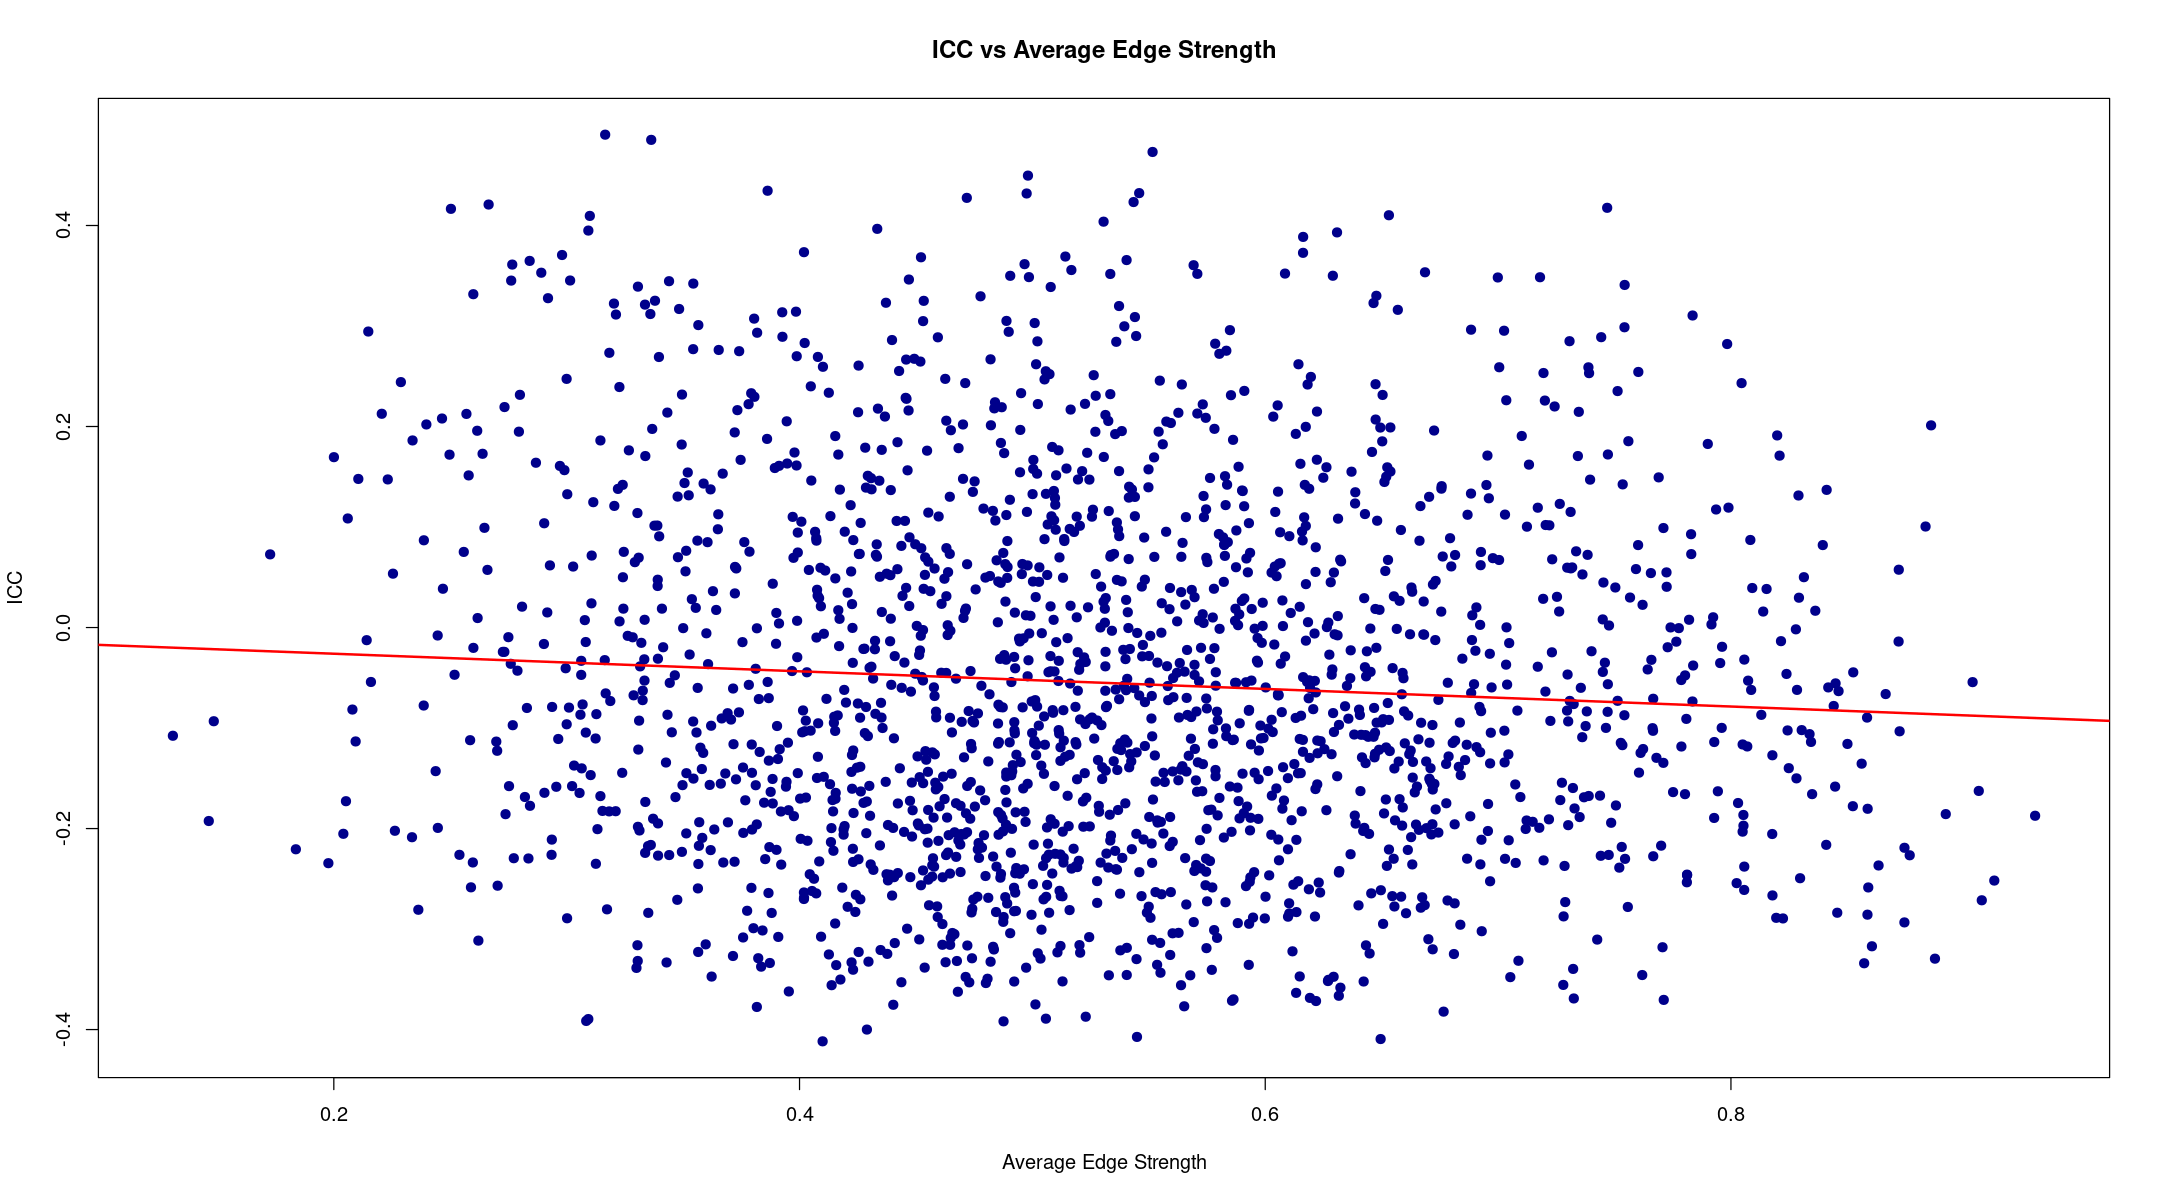

In [41]:
mean_icc <- mean(icc_vals$ICC, na.rm = TRUE)
cat("Mean ICC across edges:", mean_icc, "\n")
median_icc <- median(icc_vals$ICC, na.rm = TRUE)
cat("Median ICC across edges:", median_icc, "\n")

boxplot(icc_vals$ICC, main = "Between-scanner reliability for each edge", ylab = "ICC", col = "skyblue")

# Calculate average edge strength across all sessions for each edge
avg_edge_strength <- sapply(edge_keys, function(edge) mean(df_fc[[edge]], na.rm = TRUE))

# Merge ICC values and average edge strength into a data frame
icc_vs_strength <- data.frame(
    edge = edge_keys,
    ICC = icc_vals$ICC,
    avg_strength = avg_edge_strength
)

# Plot ICC versus average edge strength
plot(
    icc_vs_strength$avg_strength, icc_vs_strength$ICC,
    xlab = "Average Edge Strength",
    ylab = "ICC",
    main = "ICC vs Average Edge Strength",
    pch = 19, col = "darkblue"
)
abline(lm(ICC ~ avg_strength, data = icc_vs_strength), col = "red", lwd = 2)

In [42]:
icc_between <- data.frame(variability_type = character(), task = character(), scanner = character(), repetition = numeric(), ICC = numeric(), summary_statistics = character(), days_diff = numeric(), slept = numeric(), stringsAsFactors = FALSE)

scanners <- unique(df_fc$scanner)
# Iterate over the three possible scanner pairs
for (i in 1:2) {
  for (j in (i + 1):3) {

    # Iterate over all possible pairs of repetition
    for (rep1 in 1:12) {
      for (rep2 in 1:12) {
        sc1 <- scanners[i]
        sc2 <- scanners[j]

        # Extract that permutation of repetitions
        df_rep <- rbind(subset(df_fc, scanner == sc1 & repetition == rep1), subset(df_fc, scanner == sc2 & repetition == rep2))

        # Indicate whether the subject slept in both sessions (slept = 2 if slept in both, 1 if slept in one, 0 if slept in none, NA if sleeping info is missing for one of the sessions)
          if (any(is.na(df_rep$slept))) {
              # If sleeping info is absent for one of the sessions, we can't know which condition this pair falls in
              slept <- NA
          } else {
              df_rep$slept <- ifelse(df_rep$slept == "Yes", 1, 0)
              slept <- sum(df_rep$slept)
          }

        # Keep only the edge column and trasnpose the dataframe
        col_names <- df_rep$scanner
        df_edges <- t(df_rep[, edge_keys])  # rows: edges, cols: scanners
        colnames(df_edges) <- col_names

        # Compute ICC(2,1)
        icc_val <- icc(df_edges, model = "twoway", type = "agreement", unit = "single")$value

        # Store the results
        icc_between <- rbind(
            icc_between,
            data.frame(
            variability_type = "between-scanner",
            task = "rest",
            scanner = paste0(scanners[i], "-", scanners[j]),
            repetition = paste0(rep1, "-", rep2),
            ICC = icc_val,
            summary_statistic = NA,
            days_diff = NA,
            slept = slept
            )
        )  
      }
    }
  }
}

head(df_rep)
head(icc_between)

,subject,session,scanner,repetition,acq_time,pe_dir,slept_rest,edge1,edge2,edge3,⋯,edge1883,edge1884,edge1885,edge1886,edge1887,edge1888,edge1889,edge1890,edge1891,slept
,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
34,001,21201030,vidafit,12,2024-09-04T22:03:14.402500,RL,Yes,0.2207215,0.3155374,0.6377107,⋯,0.2581914,0.2360812,0.2896772,0.5450486,0.3004227,0.3408289,0.3524414,0.4587018,0.2901794,1
35,001,21202034,vida,12,2024-09-04T23:53:45.627500,LR,No,0.3348681,0.3999343,0.6203486,⋯,0.4871123,0.4053256,0.3718582,0.5936710,0.3764830,0.4621020,0.3729554,0.3276582,0.5341707,0


,variability_type,task,scanner,repetition,ICC,summary_statistic,days_diff,slept
,<chr>,<chr>,<chr>,<chr>,<dbl>,<lgl>,<lgl>,<dbl>
1,between-scanner,rest,prisma-vidafit,1-1,0.4202737,NA,NA,1
2,between-scanner,rest,prisma-vidafit,1-2,0.4522678,NA,NA,1
3,between-scanner,rest,prisma-vidafit,1-3,0.4727037,NA,NA,1
4,between-scanner,rest,prisma-vidafit,1-4,0.8813157,NA,NA,2
5,between-scanner,rest,prisma-vidafit,1-5,0.6174093,NA,NA,2
6,between-scanner,rest,prisma-vidafit,1-6,0.4560231,NA,NA,1


In [43]:
mean_icc <- mean(icc_between$ICC, na.rm = TRUE)
cat("Mean ICC across edges:", mean_icc, "\n")
quantiles <- quantile(icc_between$ICC, probs = c(0.25, 0.5, 0.75), na.rm = TRUE)
cat("Quantiles (25%, median, 75%):", quantiles, "\n")

icc_between <- rbind(
    icc_between,
    data.frame(variability_type="between-scanner", task="rest", scanner=NA, repetition=NA, ICC = mean_icc, summary_statistic = "mean", days_diff = NA, slept = NA),
    data.frame(variability_type="between-scanner", task="rest", scanner=NA, repetition=NA, ICC = quantiles[2], summary_statistic = "median", days_diff = NA, slept = NA),
    data.frame(variability_type="between-scanner", task="rest", scanner=NA, repetition=NA, ICC = quantiles[1], summary_statistic = "quantile_25", days_diff = NA, slept = NA),
    data.frame(variability_type="between-scanner", task="rest", scanner=NA, repetition=NA, ICC = quantiles[3], summary_statistic = "quantile_75", days_diff = NA, slept = NA)
)

Mean ICC across edges: 0.5880701 
Quantiles (25%, median, 75%): 0.4041885 0.5555581 0.8016743 


## ICC to quantify intra-scanner variability when using standard resting-state

Let's quantify the intra-scanner reliability of FC estimates when using the standard fixation cross task for resting-state.

### Using all 12 sessions

In [44]:
icc_within_rest <- list()
for (scanner in unique(df_fc$scanner)) {
    df_scanner <- df_fc[df_fc$scanner == scanner, ]
    df_scanner <- t(df_scanner[, edge_keys])
    icc_within_rest[[scanner]] <- icc(df_scanner, model = "twoway", type = "agreement", unit = "single")$value
    cat(sprintf("ICC of for %s scanner: %.4f\n", scanner, icc_within_rest[[scanner]]))
}
head(df_scanner)

ICC of for prisma scanner: 0.5600
ICC of for vidafit scanner: 0.5330
ICC of for vida scanner: 0.6345


,3,6,8,11,14,16,19,23,27,30,31,35
edge1,0.5496409,0.5096338,0.4131504,0.4449821,0.4811377,0.4517719,0.14202430,0.4132667,0.6015462,0.4562355,0.4532706,0.3348681
edge2,0.6378708,0.6318354,0.3158849,0.5041109,0.5994747,0.5578053,0.58822103,0.5496495,0.6282911,0.4788228,0.5092740,0.3999343
edge3,0.6992454,0.6954506,0.7255366,0.7121464,0.6295779,0.8051219,0.15598399,0.7147821,0.7653149,0.6726379,0.7430331,0.6203486
edge4,0.7256449,0.7096535,0.6781975,0.7078274,0.7546007,0.7273291,0.74348573,0.6888926,0.6716462,0.6576057,0.6938245,0.6305883
edge5,0.4162345,0.3095280,0.3174185,0.3909103,0.3908073,0.4687818,0.08717465,0.4091270,0.4564391,0.3178301,0.2573947,0.1123629
edge6,0.5537715,0.4565463,0.3077499,0.4390451,0.5227392,0.5188716,0.59198707,0.4663180,0.4230545,0.2656652,0.2658177,0.1841879


### Bootstrap all possible pairs of repetitions

In [45]:
icc_intra_rest <- data.frame(variability_type = character(), task = character(), scanner = character(), repetition = numeric(), ICC = numeric(), summary_statistics = character(), days_diff = numeric(), slept = numeric(), stringsAsFactors = FALSE)

for (scanner in unique(df_fc$scanner)) {
    df_scanner <- df_fc[df_fc$scanner == scanner, ]
    # Iterate over all possible pairs of repetition
    for (rep1 in 1:11) {
      # Ensure rep2 is always greater than rep1 to avoid duplicates
      for (rep2 in (rep1+1):12) {

            # Extract that permutation of repetitions
            df_rep <- rbind(subset(df_scanner, repetition == rep1), subset(df_scanner, repetition == rep2))
            # Compute how many days apart the two repetitions are
            days_diff <- as.numeric(abs(as.Date(df_rep$acq_time[1]) - as.Date(df_rep$acq_time[2])))
            # Indicate whether the subject slept in both sessions (slept = 2 if slept in both, 1 if slept in one, 0 if slept in none, NA if sleeping info is missing for one of the sessions)
            if (any(is.na(df_rep$slept))) {
                # If sleeping info is absent for one of the sessions, we can't know which condition this pair falls in
                slept <- NA
            } else {
                df_rep$slept <- ifelse(df_rep$slept == "Yes", 1, 0)
                slept <- sum(df_rep$slept)
            }

            #Keep only the edge column and transpose the dataframe
            df_rep <- t(df_rep[, edge_keys])

            # Compute ICC(2,1)
            icc_val <- icc(df_rep, model = "twoway", type = "agreement", unit = "single")$value
            icc_intra_rest <- rbind(icc_intra_rest, data.frame(variability_type = "within-scanner", task="rest", scanner=scanner, repetition = paste0(rep1, "-", rep2), ICC = icc_val, summary_statistic = NA, days_diff = days_diff, slept=slept))
        }
    }
}
head(df_rep)
head(icc_intra_rest)

,31,35
edge1,0.4532706,0.3348681
edge2,0.5092740,0.3999343
edge3,0.7430331,0.6203486
edge4,0.6938245,0.6305883
edge5,0.2573947,0.1123629
edge6,0.2658177,0.1841879


,variability_type,task,scanner,repetition,ICC,summary_statistic,days_diff,slept
,<chr>,<chr>,<chr>,<chr>,<dbl>,<lgl>,<dbl>,<dbl>
1,within-scanner,rest,prisma,1-2,0.8104636,NA,1,2
2,within-scanner,rest,prisma,1-3,0.7115025,NA,2,2
3,within-scanner,rest,prisma,1-4,0.4187486,NA,3,1
4,within-scanner,rest,prisma,1-5,0.4241301,NA,4,1
5,within-scanner,rest,prisma,1-6,0.7735494,NA,5,2
6,within-scanner,rest,prisma,1-7,0.5158890,NA,7,1


In [46]:
for (scanner in unique(df_fc$scanner)) {
    icc_intra_rest_scanner <- icc_intra_rest[icc_intra_rest$scanner == scanner, ]
    mean_icc <- mean(icc_intra_rest_scanner$ICC, na.rm = TRUE)
    cat("Scanner:", scanner, "\n")
    cat("Mean ICC across edges:", mean_icc, "\n")
    quantiles <- quantile(icc_intra_rest_scanner$ICC, probs = c(0.25, 0.5, 0.75), na.rm = TRUE)
    cat("Quantiles (25%, median, 75%):", quantiles, "\n")

    icc_intra_rest <- rbind(
        icc_intra_rest,
        data.frame(variability_type="within-scanner", task="rest", scanner=scanner, repetition=NA, ICC = mean_icc, summary_statistic = "mean", days_diff = NA, slept = slept),
        data.frame(variability_type="within-scanner", task="rest", scanner=scanner, repetition=NA, ICC = quantiles[2], summary_statistic = "median", days_diff = NA, slept = slept),
        data.frame(variability_type="within-scanner", task="rest", scanner=scanner, repetition=NA, ICC = quantiles[1], summary_statistic = "quantile_25", days_diff = NA, slept = slept),
        data.frame(variability_type="within-scanner", task="rest", scanner=scanner, repetition=NA, ICC = quantiles[3], summary_statistic = "quantile_75", days_diff = NA, slept = slept)
    )
}

Scanner: prisma 
Mean ICC across edges: 0.5652956 
Quantiles (25%, median, 75%): 0.387248 0.4742039 0.7801331 
Scanner: vidafit 
Mean ICC across edges: 0.5592037 
Quantiles (25%, median, 75%): 0.3009559 0.570787 0.8095756 
Scanner: vida 
Mean ICC across edges: 0.6447866 
Quantiles (25%, median, 75%): 0.5280224 0.6745361 0.7960005 


## ICC to quantify intra-scanner variability when using naturalistic movie

### Using all 36 sessions

In [47]:
df_intra_rsmovie <- t(df_rsmovie[, edge_keys])
head(df_intra_rsmovie)
icc_val_intra_rsmovie <- icc(df_intra_rsmovie, model = "twoway", type = "agreement", unit = "single")$value
cat(sprintf("ICC for rsmovie: %.4f\n", icc_val_intra_rsmovie))

edge1,0.6216386,0.6403972,0.5412989,0.5346348,0.6104283,0.6035920,0.4466778,0.5050477,0.5457476,0.4679785,⋯,0.4544409,0.5153529,0.5399256,0.5702904,0.5435963,0.4820986,0.3642394,0.4611147,0.5162571,0.3266557
edge2,0.5941284,0.6621736,0.5264868,0.5345418,0.5184101,0.5604684,0.4374828,0.5460433,0.5107944,0.4278021,⋯,0.4923441,0.5952549,0.5841836,0.6445598,0.5662279,0.5802214,0.5269814,0.6362241,0.6555242,0.4594529
edge3,0.7133108,0.6845539,0.5850952,0.7297089,0.6750612,0.7381508,0.5461094,0.6531540,0.6263609,0.5706040,⋯,0.6516860,0.6295478,0.7052182,0.6908451,0.7591276,0.6104920,0.4961447,0.6615232,0.6219265,0.5014879
edge4,0.7408829,0.7714371,0.7457973,0.7591273,0.7632487,0.7389312,0.7470424,0.7875297,0.7609913,0.7715509,⋯,0.7342332,0.7985510,0.6935204,0.6814568,0.7530195,0.6772000,0.6578069,0.6618083,0.6505799,0.6379796
edge5,0.5368403,0.4925515,0.4392278,0.4969488,0.5269248,0.4902849,0.3974737,0.4672775,0.3960080,0.3813823,⋯,0.2556588,0.4521184,0.3283802,0.5248521,0.4698423,0.4506773,0.3867090,0.4423098,0.3995207,0.3442520
edge6,0.5454009,0.5587658,0.4729301,0.4852340,0.5158932,0.5434923,0.3848835,0.4091123,0.2955827,0.2487566,⋯,0.2095474,0.3972067,0.3930193,0.4314876,0.5344769,0.4469067,0.3842306,0.5614531,0.4758118,0.3496748


ICC for rsmovie: 0.7783


### Bootstrap to permute through all possible pairs of repetitions

In [48]:
icc_intra_rsmovie <- data.frame(variability_type = character(), task = character(), scanner = character(), repetition = numeric(), ICC = numeric(), summary_statistics = character(), days_diff = numeric(),slept = numeric(), stringsAsFactors = FALSE)

# Iterate over all possible pairs of repetition
for (rep1 in 1:35) {
  # Ensure rep2 is always greater than rep1 to avoid duplicates
  for (rep2 in (rep1+1):36) {

        # Extract that permutation of repetitions
        df_rep <- rbind(subset(df_rsmovie, repetition == rep1), subset(df_rsmovie, repetition == rep2))
        # Compute how many days apart the two repetitions are
        days_diff <- as.numeric(abs(as.Date(df_rep$acq_time[1]) - as.Date(df_rep$acq_time[2])))
        # Indicate whether the subject slept in both sessions (slept = 2 if slept in both, 1 if slept in one, 0 if slept in none, NA if sleeping info is missing for one of the sessions)
            if (any(is.na(df_rep$slept))) {
                # If sleeping info is absent for one of the sessions, we can't know which condition this pair falls in
                slept <- NA
            } else {
                df_rep$slept <- ifelse(df_rep$slept == "Yes", 1, 0)
                slept <- sum(df_rep$slept)
            }
        
        #Keep only the edge column and transpose the dataframe
        df_rep <- t(df_rep[, edge_keys])

        # Compute ICC(2,1)
        icc_val <- icc(df_rep, model = "twoway", type = "agreement", unit = "single")$value
        icc_intra_rsmovie <- rbind(icc_intra_rsmovie, data.frame(variability_type = "within-scanner", task="rsmovie", scanner="prisma", repetition = paste0(rep1, "-", rep2), ICC = icc_val, summary_statistic = NA, days_diff = days_diff, slept=slept))
    }
}
head(df_rep)
head(icc_intra_rsmovie)

,35,36
edge1,0.5162571,0.3266557
edge2,0.6555242,0.4594529
edge3,0.6219265,0.5014879
edge4,0.6505799,0.6379796
edge5,0.3995207,0.3442520
edge6,0.4758118,0.3496748


,variability_type,task,scanner,repetition,ICC,summary_statistic,days_diff,slept
,<chr>,<chr>,<chr>,<chr>,<dbl>,<lgl>,<dbl>,<dbl>
1,within-scanner,rsmovie,prisma,1-2,0.8197148,NA,1,NA
2,within-scanner,rsmovie,prisma,1-3,0.8884523,NA,1,NA
3,within-scanner,rsmovie,prisma,1-4,0.9148769,NA,2,NA
4,within-scanner,rsmovie,prisma,1-5,0.8285133,NA,2,NA
5,within-scanner,rsmovie,prisma,1-6,0.7563433,NA,3,NA
6,within-scanner,rsmovie,prisma,1-7,0.7923917,NA,3,NA


In [49]:
mean_icc <- mean(icc_intra_rsmovie$ICC, na.rm = TRUE)
cat("Mean ICC across edges:", mean_icc, "\n")
quantiles <- quantile(icc_intra_rsmovie$ICC, probs = c(0.25, 0.5, 0.75), na.rm = TRUE)
cat("Quantiles (25%, median, 75%):", quantiles, "\n")

icc_intra_rsmovie <- rbind(
    icc_intra_rsmovie,
    data.frame(variability_type="within-scanner", task="rsmovie", scanner="prisma", repetition=NA, ICC = mean_icc, summary_statistic = "mean", days_diff = NA, slept = NA),
    data.frame(variability_type="within-scanner", task="rsmovie", scanner="prisma", repetition=NA, ICC = quantiles[2], summary_statistic = "median", days_diff = NA, slept = NA),
    data.frame(variability_type="within-scanner", task="rsmovie", scanner="prisma", repetition=NA, ICC = quantiles[1], summary_statistic = "quantile_25", days_diff = NA, slept = NA),
    data.frame(variability_type="within-scanner", task="rsmovie", scanner="prisma", repetition=NA, ICC = quantiles[3], summary_statistic = "quantile_75", days_diff = NA, slept = NA)
)

Mean ICC across edges: 0.7829362 
Quantiles (25%, median, 75%): 0.7299645 0.8061051 0.8455674 


## ICC to quantify variability across paradigms

In [50]:
icc_vals <- data.frame(edge = character(), ICC = numeric(), stringsAsFactors = FALSE)

# Randomly select 12 sessions from the rsmovie task because we need to have the same number of sessions for each task to be able to compute ICC
selected_sessions <- sample(unique(df_fc_paradigm$repetition[df_fc_paradigm$task == "rsmovie"]), 12)
df_paradigm <- df_fc_paradigm[df_fc_paradigm$repetition %in% selected_sessions | df_fc_paradigm$task == "rest", ]

for (edge in edge_keys) {
    # Keep only the edge and session columns
    df_icc <- df_paradigm[, c( "task", edge)]
    df_icc <- pivot_wider(df_icc, names_from = task, values_from = edge, values_fn = list)
    df_icc <- unnest(df_icc, cols = c(rest, rsmovie))
    # Compute ICC(2,1) for this edge
    icc_val <- icc(df_icc, model = "twoway", type = "agreement", unit = "single")$value
    icc_vals <- rbind(icc_vals, data.frame(edge = edge, ICC = icc_val))
}
df_icc
head(icc_vals)

rest,rsmovie
<dbl>,<dbl>
0.3620068,0.5179920
0.4216522,0.7270293
0.3304195,0.7109889
0.5405864,0.6797545
0.5553758,0.6863294
0.5059431,0.6043138
0.4990836,0.5694896
0.6696954,0.6332948
0.4960707,0.6943303


,edge,ICC
,<chr>,<dbl>
1,edge1,-0.07948244
2,edge2,-0.23262110
3,edge3,-0.14093868
4,edge4,-0.19106711
5,edge5,-0.13547931
6,edge6,-0.06783504


Mean ICC across edges: -0.06098148 
Median ICC across edges: -0.04625858 


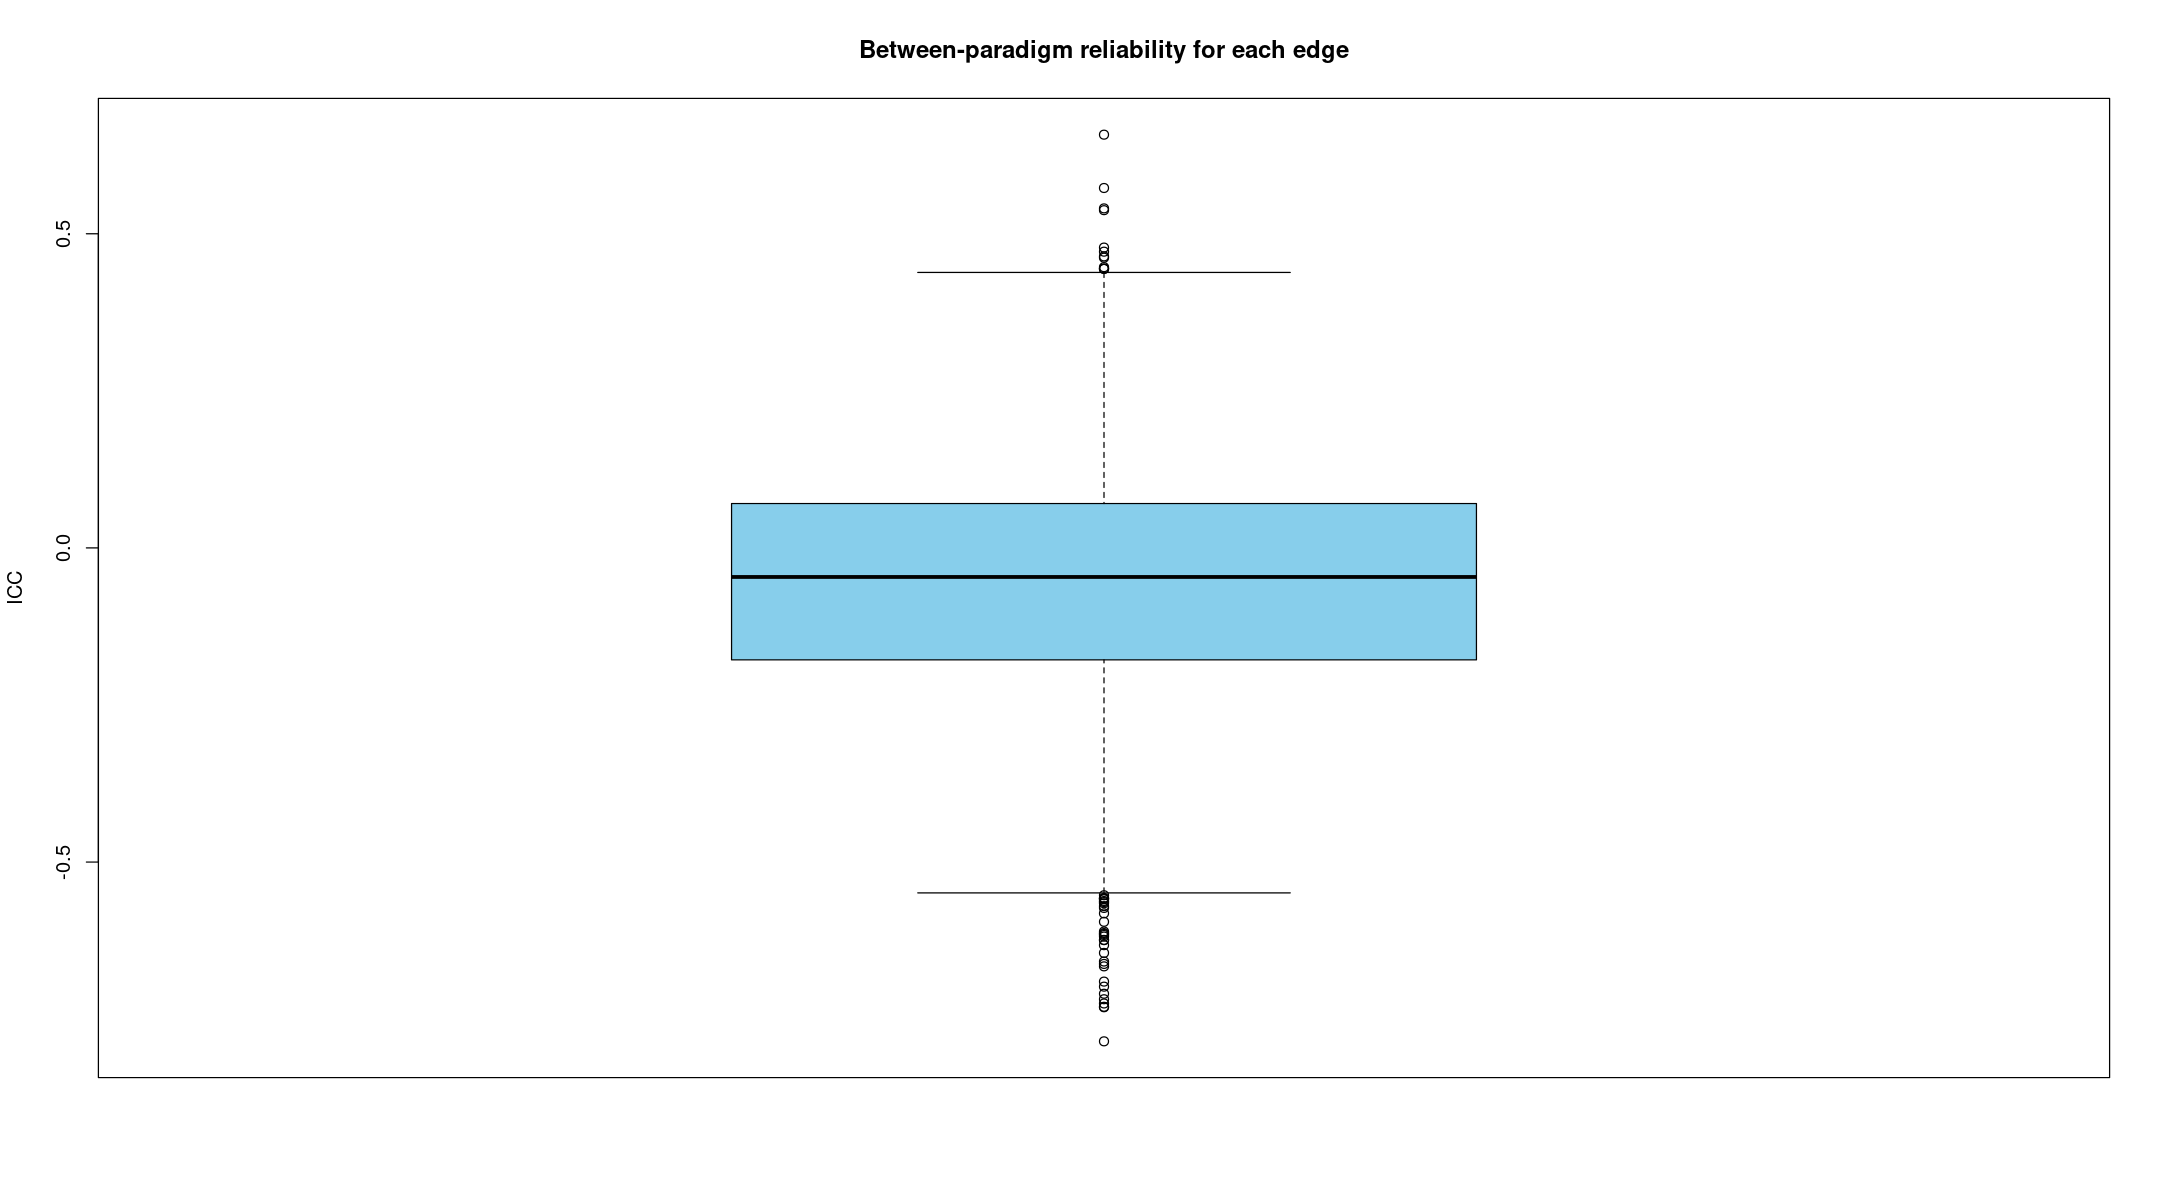

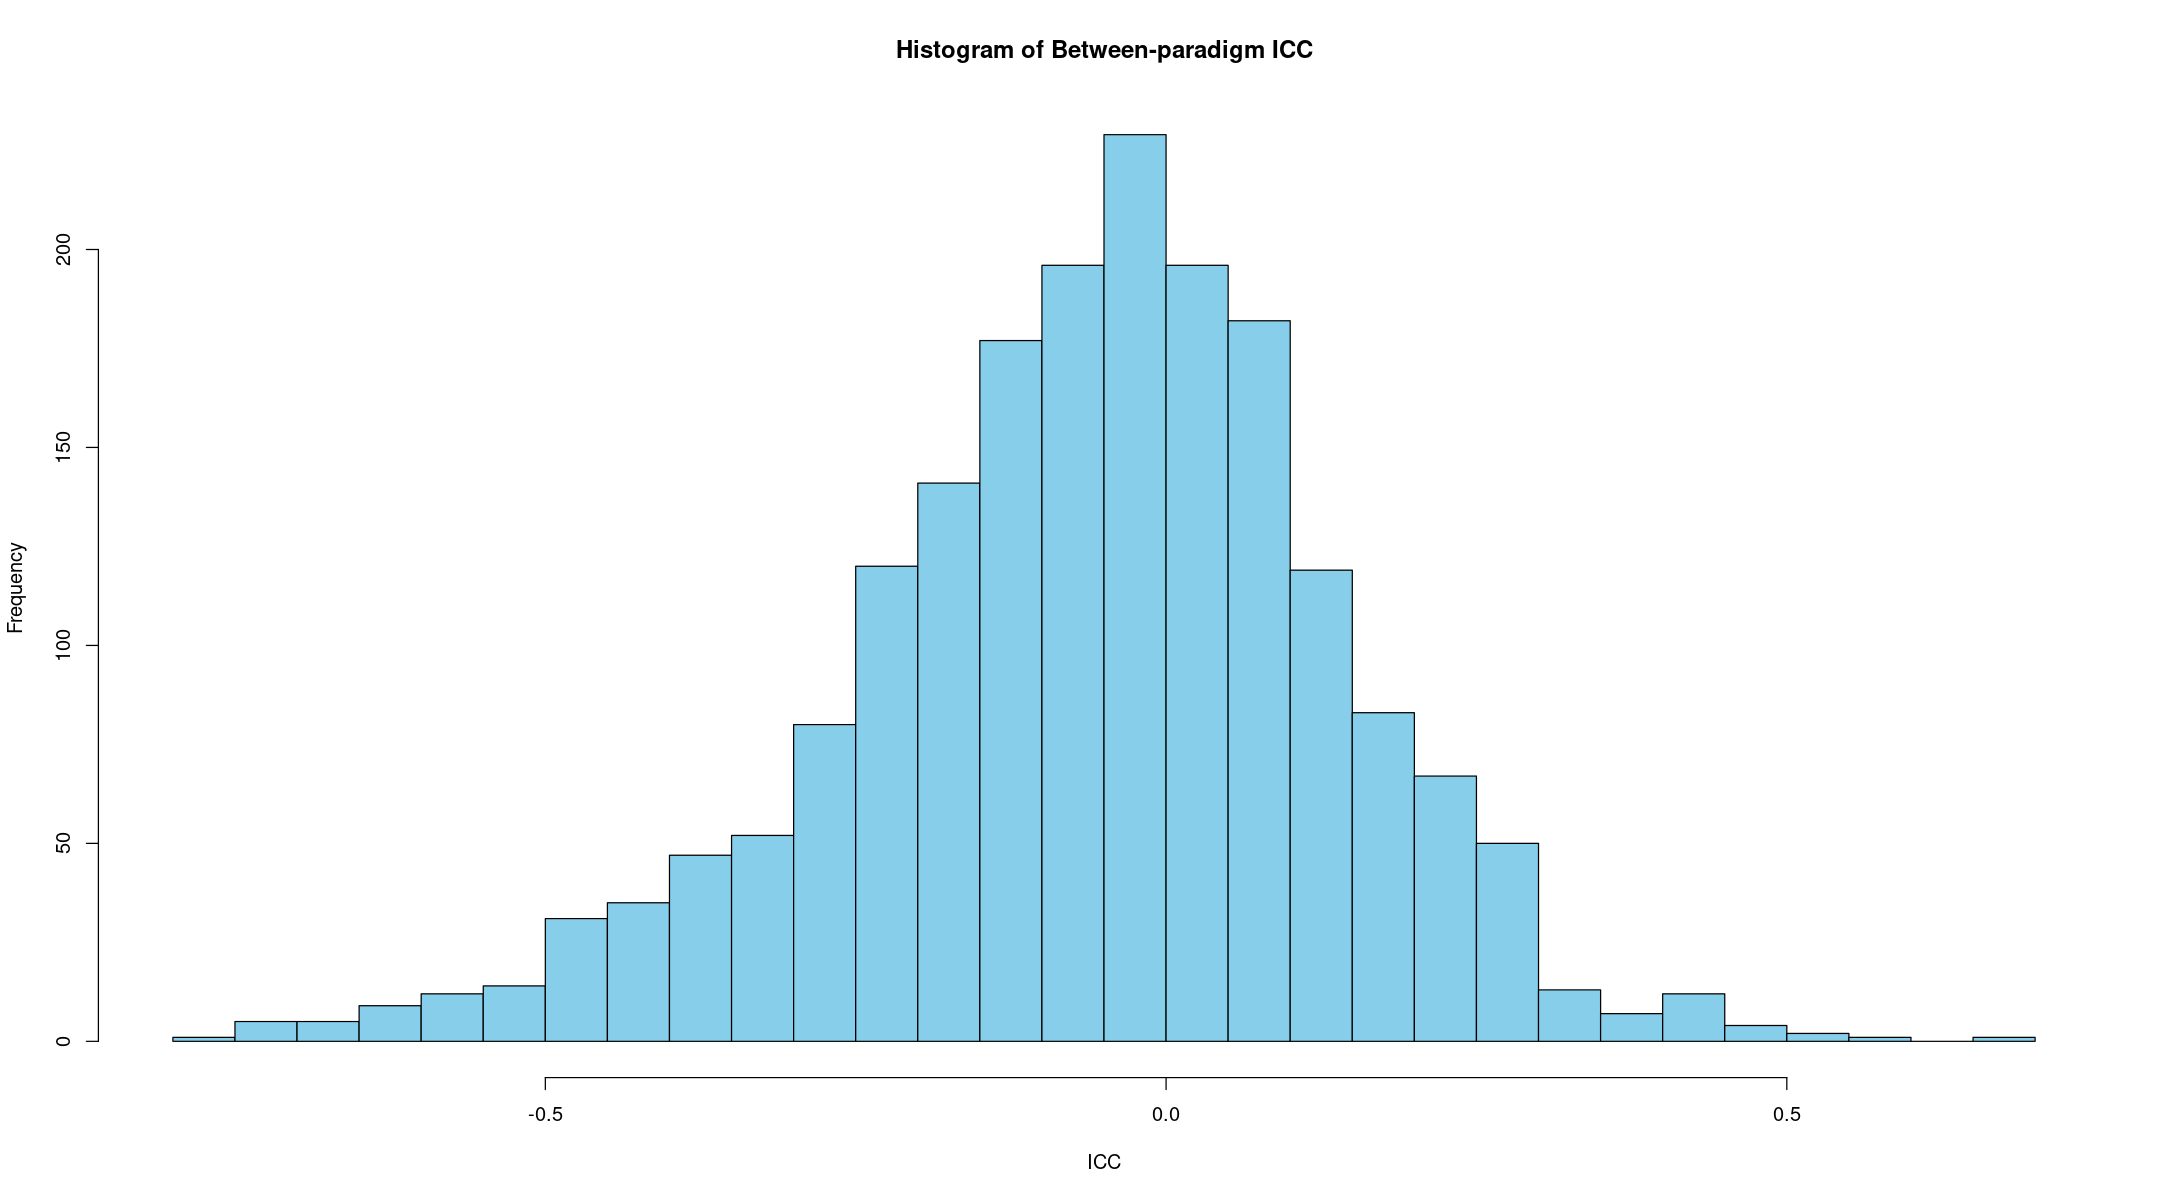

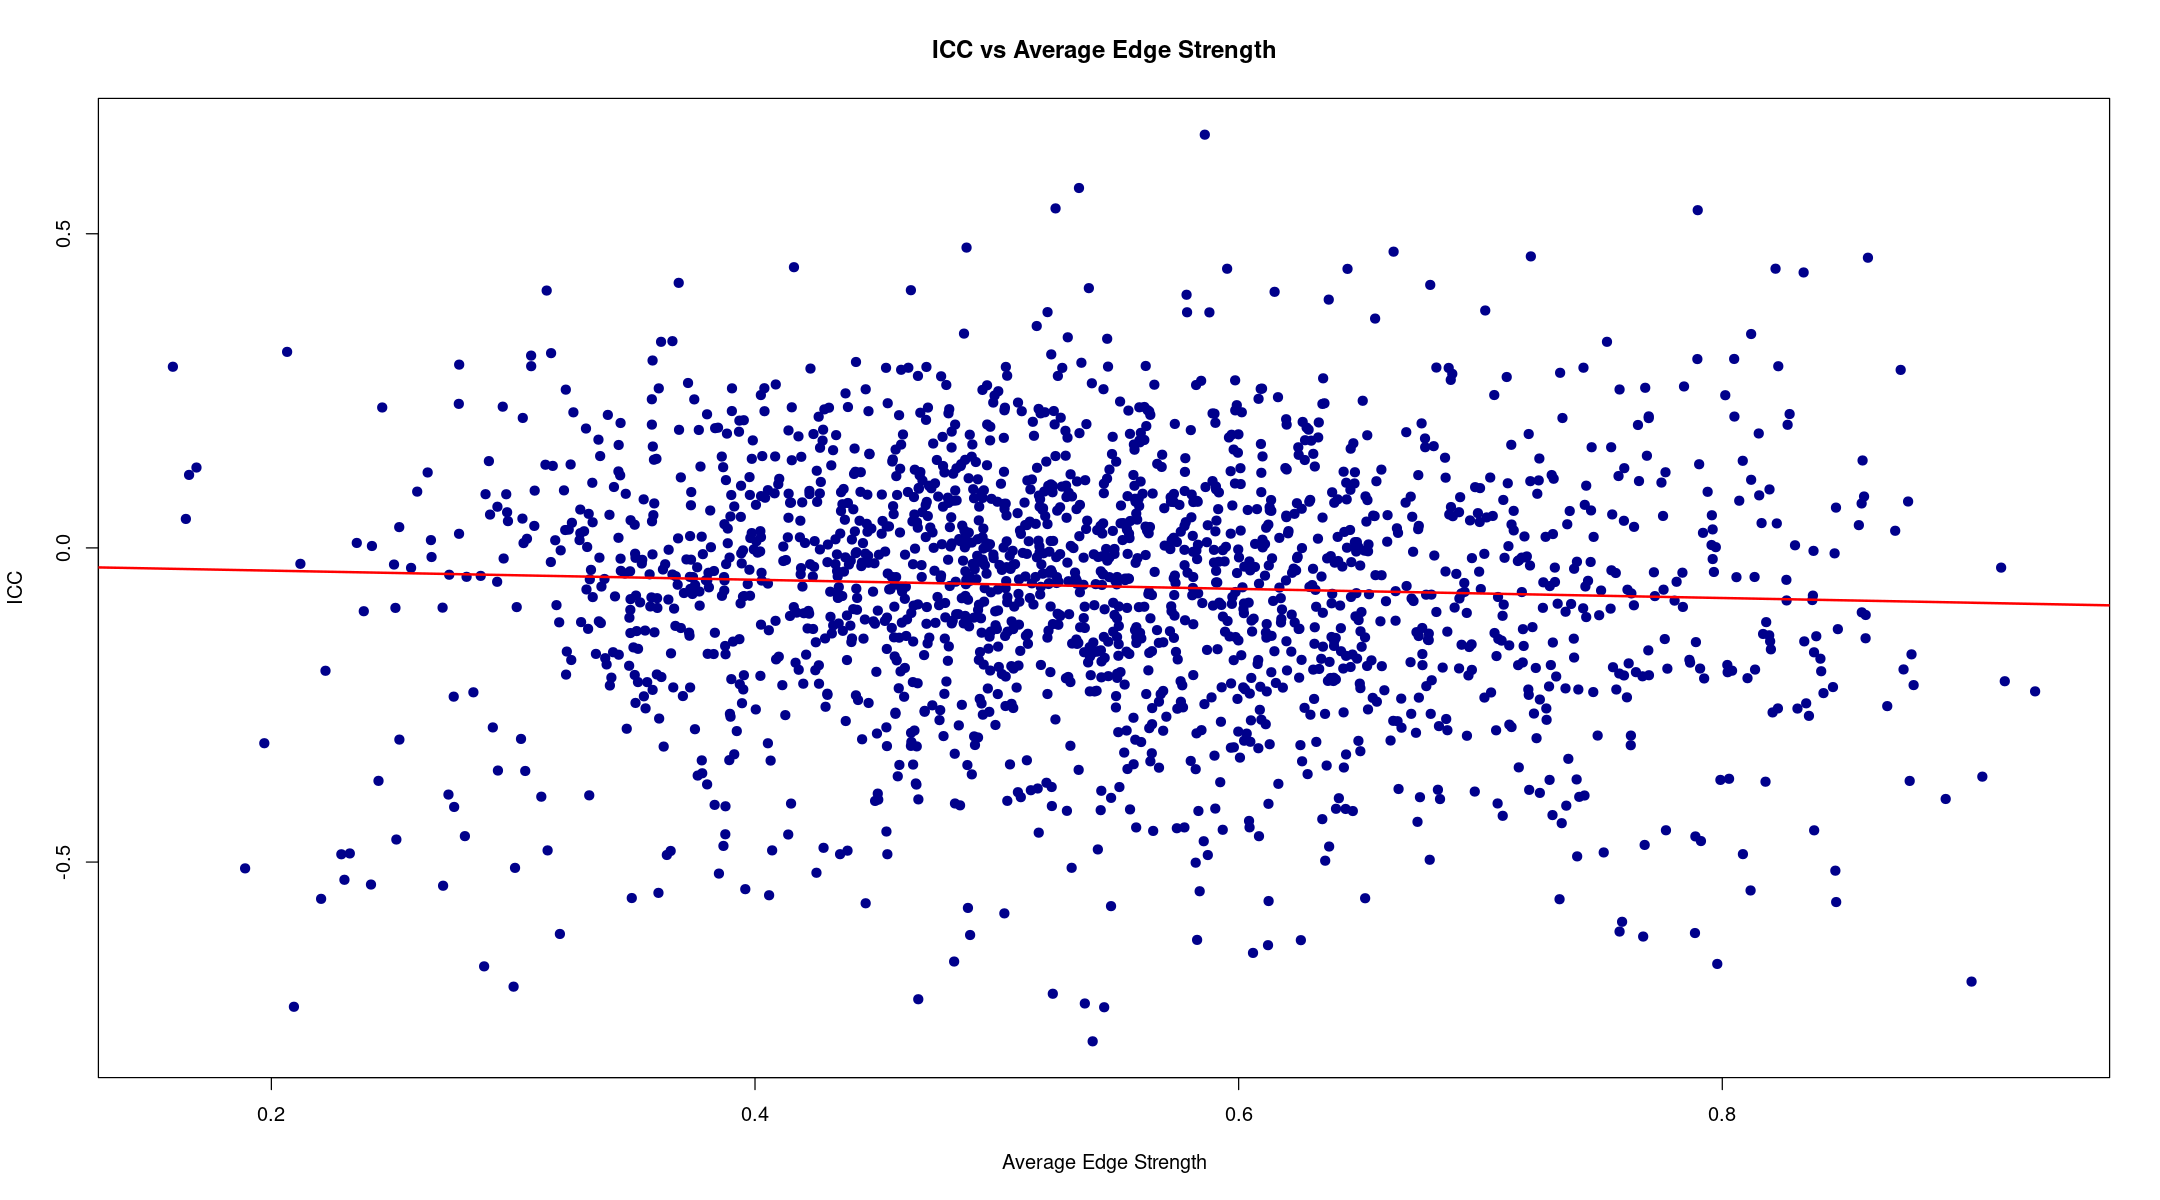

In [51]:
mean_icc <- mean(icc_vals$ICC, na.rm = TRUE)
cat("Mean ICC across edges:", mean_icc, "\n")
median_icc <- median(icc_vals$ICC, na.rm = TRUE)
cat("Median ICC across edges:", median_icc, "\n")

boxplot(icc_vals$ICC, main = "Between-paradigm reliability for each edge", ylab = "ICC", col = "skyblue")
hist(icc_vals$ICC, breaks = 30, main = "Histogram of Between-paradigm ICC", xlab = "ICC", col = "skyblue")

# Calculate average edge strength across all sessions for each edge
avg_edge_strength <- sapply(edge_keys, function(edge) mean(df_paradigm[[edge]], na.rm = TRUE))

# Merge ICC values and average edge strength into a data frame
icc_vs_strength <- data.frame(
    edge = edge_keys,
    ICC = icc_vals$ICC,
    avg_strength = avg_edge_strength
)

# Plot ICC versus average edge strength
plot(
    icc_vs_strength$avg_strength, icc_vs_strength$ICC,
    xlab = "Average Edge Strength",
    ylab = "ICC",
    main = "ICC vs Average Edge Strength",
    pch = 19, col = "darkblue"
)
abline(lm(ICC ~ avg_strength, data = icc_vs_strength), col = "red", lwd = 2)

In [52]:
icc_paradigm <- data.frame(variability_type = character(), task = character(), scanner = character(), repetition = numeric(), ICC = numeric(), summary_statistics = character(), days_diff = numeric(), slept= numeric(), stringsAsFactors = FALSE)

# Iterate over all possible combinations of repetition numbers for the 3 scanners
tasks <- unique(df_fc_paradigm$task)
for (rep1 in 1:12) {
  for (rep2 in 1:36) {

        # Extract that permutation of repetitions
        reps <- c(rep1, rep2)
        df_rep <- data.frame()
        for (i in 1:2) {
          df_one <- subset(df_fc_paradigm, task == tasks[i] & repetition == reps[i])
          df_rep <- rbind(df_rep, df_one)
        }
        # Indicate whether the subject slept in both sessions (slept = 2 if slept in both, 1 if slept in one, 0 if slept in none, NA if sleeping info is missing for one of the sessions)
        if (any(is.na(df_rep$slept))) {
            # If sleeping info is absent for one of the sessions, we can't know which condition this pair falls in
            slept <- NA
        } else {
            df_rep$slept <- ifelse(df_rep$slept == "Yes", 1, 0)
            slept <- sum(df_rep$slept)
        }
        colnames <- df_rep$task
        df_rep <- t(df_rep[, edge_keys])
        colnames(df_rep) <- colnames
        # Compute ICC(2,1) for this edge
        icc_val <- icc(df_rep, model = "twoway", type = "agreement", unit = "single")$value
        icc_paradigm <- rbind(icc_paradigm, data.frame(variability_type = "between-paradigm", task=NA, scanner="prisma", repetition = paste0(rep1, "-", rep2), ICC = icc_val, summary_statistic = NA, days_diff = days_diff, slept = slept))
    }
}
head(df_rep)
head(icc_paradigm)

,rest,rsmovie
edge1,0.3995341,0.3266557
edge2,0.4532716,0.4594529
edge3,0.7270787,0.5014879
edge4,0.7265083,0.6379796
edge5,0.3396650,0.3442520
edge6,0.3066537,0.3496748


,variability_type,task,scanner,repetition,ICC,summary_statistic,days_diff,slept
,<chr>,<lgl>,<chr>,<chr>,<dbl>,<lgl>,<dbl>,<dbl>
1,between-paradigm,NA,prisma,1-1,0.4166026,NA,0,NA
2,between-paradigm,NA,prisma,1-2,0.4740292,NA,0,NA
3,between-paradigm,NA,prisma,1-3,0.4793847,NA,0,1
4,between-paradigm,NA,prisma,1-4,0.4170954,NA,0,1
5,between-paradigm,NA,prisma,1-5,0.3687580,NA,0,1
6,between-paradigm,NA,prisma,1-6,0.5041669,NA,0,1


In [53]:
mean_icc <- mean(icc_paradigm$ICC, na.rm = TRUE)
cat("Mean ICC across edges:", mean_icc, "\n")
quantiles <- quantile(icc_paradigm$ICC, probs = c(0.25, 0.5, 0.75), na.rm = TRUE)
cat("Quantiles (25%, median, 75%):", quantiles, "\n")

icc_paradigm <- rbind(
    icc_paradigm,
    data.frame(variability_type="between-paradigm", task=NA, scanner="prisma", repetition=NA, ICC = mean_icc, summary_statistic = "mean", days_diff = NA, slept = NA),
    data.frame(variability_type="between-paradigm", task=NA, scanner="prisma", repetition=NA, ICC = quantiles[2], summary_statistic = "median", days_diff = NA, slept = NA),
    data.frame(variability_type="between-paradigm", task=NA, scanner="prisma", repetition=NA, ICC = quantiles[1], summary_statistic = "quantile_25", days_diff = NA, slept = NA),
    data.frame(variability_type="between-paradigm", task=NA, scanner="prisma", repetition=NA, ICC = quantiles[3], summary_statistic = "quantile_75", days_diff = NA, slept = NA)
)

Mean ICC across edges: 0.5649815 
Quantiles (25%, median, 75%): 0.40602 0.5326702 0.7256168 


## Save the ICC estimates in a table

We use pybids to determine the filename to save the table.

In [54]:
py_run_string(" 
save_path = Path('/data/derivatives/hcph-suppl/')
save_layout = BIDSLayout(save_path, config='hcph', indexer=_indexer, validate=False)
entities = {
    'experiment': 'scannereffects',
    'extension': '.tsv',
    'datatype': 'tables',
    'suffix': 'bold',
    'desc': 'icc'
}
entities.update(entities_base)
save_path = save_layout.build_path(entities, validate=False)
#")

In [55]:
icc_results <- rbind(icc_between, icc_paradigm, icc_intra_rsmovie, icc_intra_rest)

write.table(icc_results, file = py$save_path, sep = "\t", row.names = FALSE, col.names = TRUE, quote = FALSE)

## Visualize the ICC results

In [89]:
py_run_string(" 
save_path = Path('/data/derivatives/hcph-suppl/')
save_layout = BIDSLayout(save_path, config='hcph', indexer=_indexer, validate=False)
entities = {
    'experiment': 'scannereffects',
    'extension': '.tsv',
    'datatype': 'tables',
    'suffix': 'bold',
    'desc': 'icc'
}
entities.update(entities_base)
save_path = save_layout.build_path(entities, validate=False)
#")

In [90]:
# Extract the measurement type from the filename
meas <- sub(".*meas-([a-zA-Z]+).*", "\\1", py$save_path)

# Determine the alternate measurement type
alt_meas <- ifelse(meas == "sparseinversecovariance", "correlation", "sparseinversecovariance")

# Construct the alternate file path
alt_save_path <- gsub(meas, alt_meas, py$save_path)

if (file.exists(py$save_path) && file.exists(alt_save_path)) {
    # Read the saved ICC results for both measurement types
    icc_results_1 <- read.table(py$save_path, sep = "\t", header = TRUE, stringsAsFactors = FALSE)
    icc_results_1$meas <- meas
    icc_results_2 <- read.table(alt_save_path, sep = "\t", header = TRUE, stringsAsFactors = FALSE)
    icc_results_2$meas <- alt_meas

    # Combine the results into a single data frame
    icc_combined <- rbind(icc_results_1, icc_results_2)
    head(icc_combined)
} else {
    cat("The following files must exist at the specified paths:\n")
    cat(py$save_path, "\n")
    cat(alt_save_path, "\n")
    cat("Please run the upper part of the notebook to compute the ICC first.")
}

,variability_type,task,scanner,repetition,ICC,summary_statistic,days_diff,slept,meas
,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,<int>,<int>,<chr>
1,between-scanner,rest,prisma-vidafit,1-1,0.4202737,NA,NA,1,correlation
2,between-scanner,rest,prisma-vidafit,1-2,0.4522678,NA,NA,1,correlation
3,between-scanner,rest,prisma-vidafit,1-3,0.4727037,NA,NA,1,correlation
4,between-scanner,rest,prisma-vidafit,1-4,0.8813157,NA,NA,2,correlation
5,between-scanner,rest,prisma-vidafit,1-5,0.6174093,NA,NA,2,correlation
6,between-scanner,rest,prisma-vidafit,1-6,0.4560231,NA,NA,1,correlation


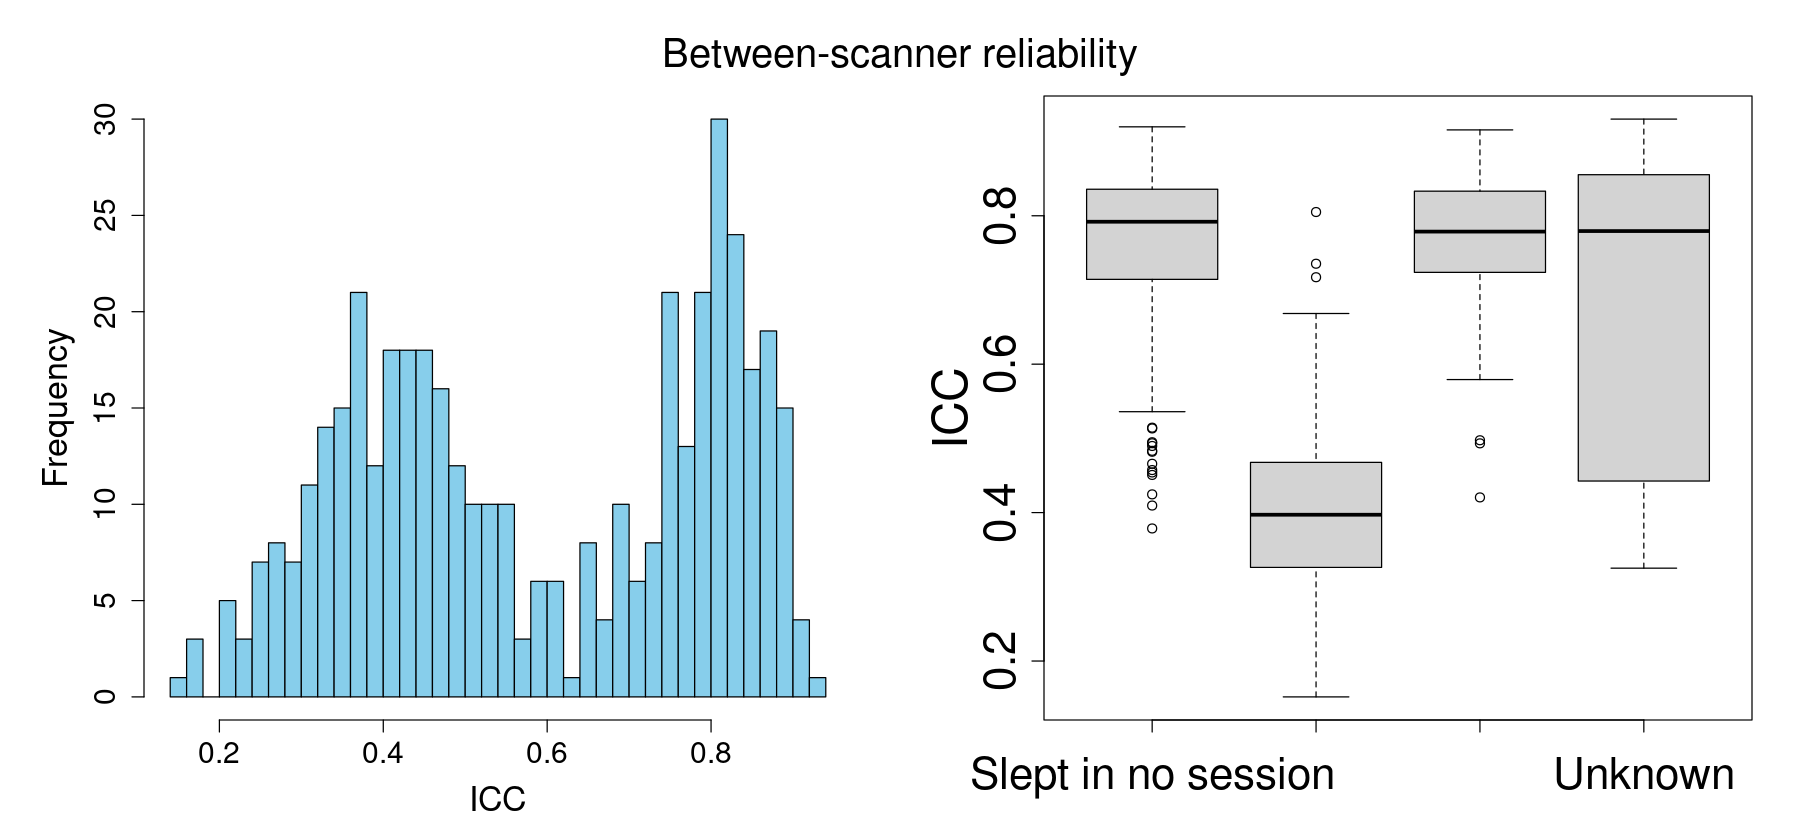

In [115]:
icc_between <- icc_combined[icc_combined$variability_type == "between-scanner" & icc_combined$meas == meas, ]
# Sleep influence on ICC
icc_between$slept_factor <- factor(
    ifelse(is.na(icc_between$slept), -1, icc_between$slept),
    levels = c(0, 1, 2, -1),
    labels = c("Slept in no session", "Slept in one session", "Slept in both sessions", "Unknown")
)

# Make the plot wider by increasing the width of the plotting window and font sizes
options(repr.plot.width = 15, repr.plot.height = 7)
par(mfrow = c(1, 2), cex.axis = 2, cex.lab = 2, cex.main = 2, cex.sub = 2, mar = c(5, 6, 4, 2))  # Increase left margin

hist(
    icc_between$ICC,
    breaks = 30,
    main = "",
    xlab = "ICC",
    ylab = "Frequency",
    col = "skyblue",
    cex.axis = 1.5,
    cex.lab = 1.7,
    cex.main = 2
)

boxplot(
    ICC ~ slept_factor, data = icc_between,
    xlab = "",
    ylab = "ICC",
    cex.axis = 2.2,
    cex.lab = 2.4,
    cex.main = 2.5,
    xaxt = "n" # suppress default x-axis
)
axis(
    side = 1,
    at = 1:4,
    labels = levels(icc_between$slept_factor),
    cex.axis = 2.2,
    padj = 0.8 # move labels lower
)
mtext("Between-scanner reliability", outer = TRUE, line = -3, cex = 2)
par(mfrow = c(1, 1))  # Reset plotting area

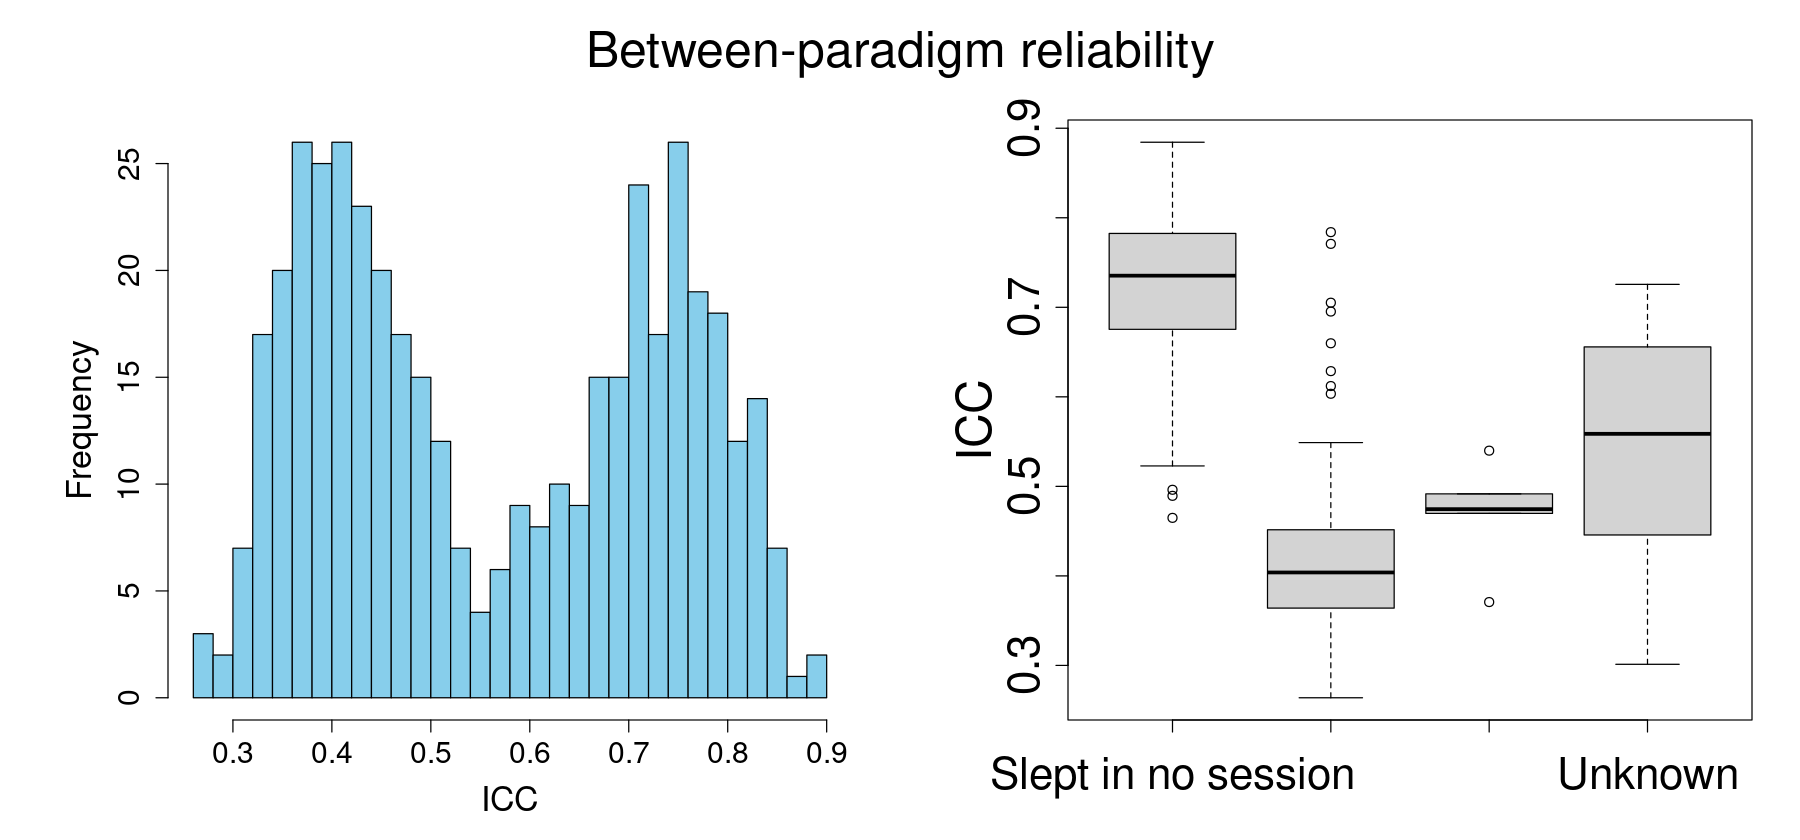

In [116]:
icc_paradigm <- icc_combined[icc_combined$variability_type == "between-paradigm" & icc_combined$meas == meas, ]
# Sleep influence on ICC
icc_paradigm$slept_factor <- factor(
    ifelse(is.na(icc_paradigm$slept), -1, icc_paradigm$slept),
    levels = c(0, 1, 2, -1),
    labels = c("Slept in no session", "Slept in one session", "Slept in both sessions", "Unknown")
)

# Make the plot wider by increasing the width of the plotting window and font sizes
options(repr.plot.width = 15, repr.plot.height = 7)
par(mfrow = c(1, 2), cex.axis = 2.2, cex.lab = 2.4, cex.main = 2.5, cex.sub = 2.2, mar = c(5, 7, 5, 2))  # Further increase font sizes
hist(
    icc_paradigm$ICC,
    breaks = 30,
    main = "",
    xlab = "ICC",
    ylab = "Frequency",
    col = "skyblue",
    cex.axis = 1.5,
    cex.lab = 1.7,
    cex.main = 2
)

boxplot(
    ICC ~ slept_factor, data = icc_paradigm,
    xlab = "",
    ylab = "ICC",
    cex.axis = 2.2,
    cex.lab = 2.4,
    cex.main = 2.5,
    xaxt = "n" # suppress default x-axis
)
axis(
    side = 1,
    at = 1:4,
    labels = levels(icc_paradigm$slept_factor),
    cex.axis = 2.2,
    padj = 0.8 # move labels lower
)
mtext("Between-paradigm reliability", outer = TRUE, line = -3, cex = 2.5)
par(mfrow = c(1, 1))  # Reset plotting area

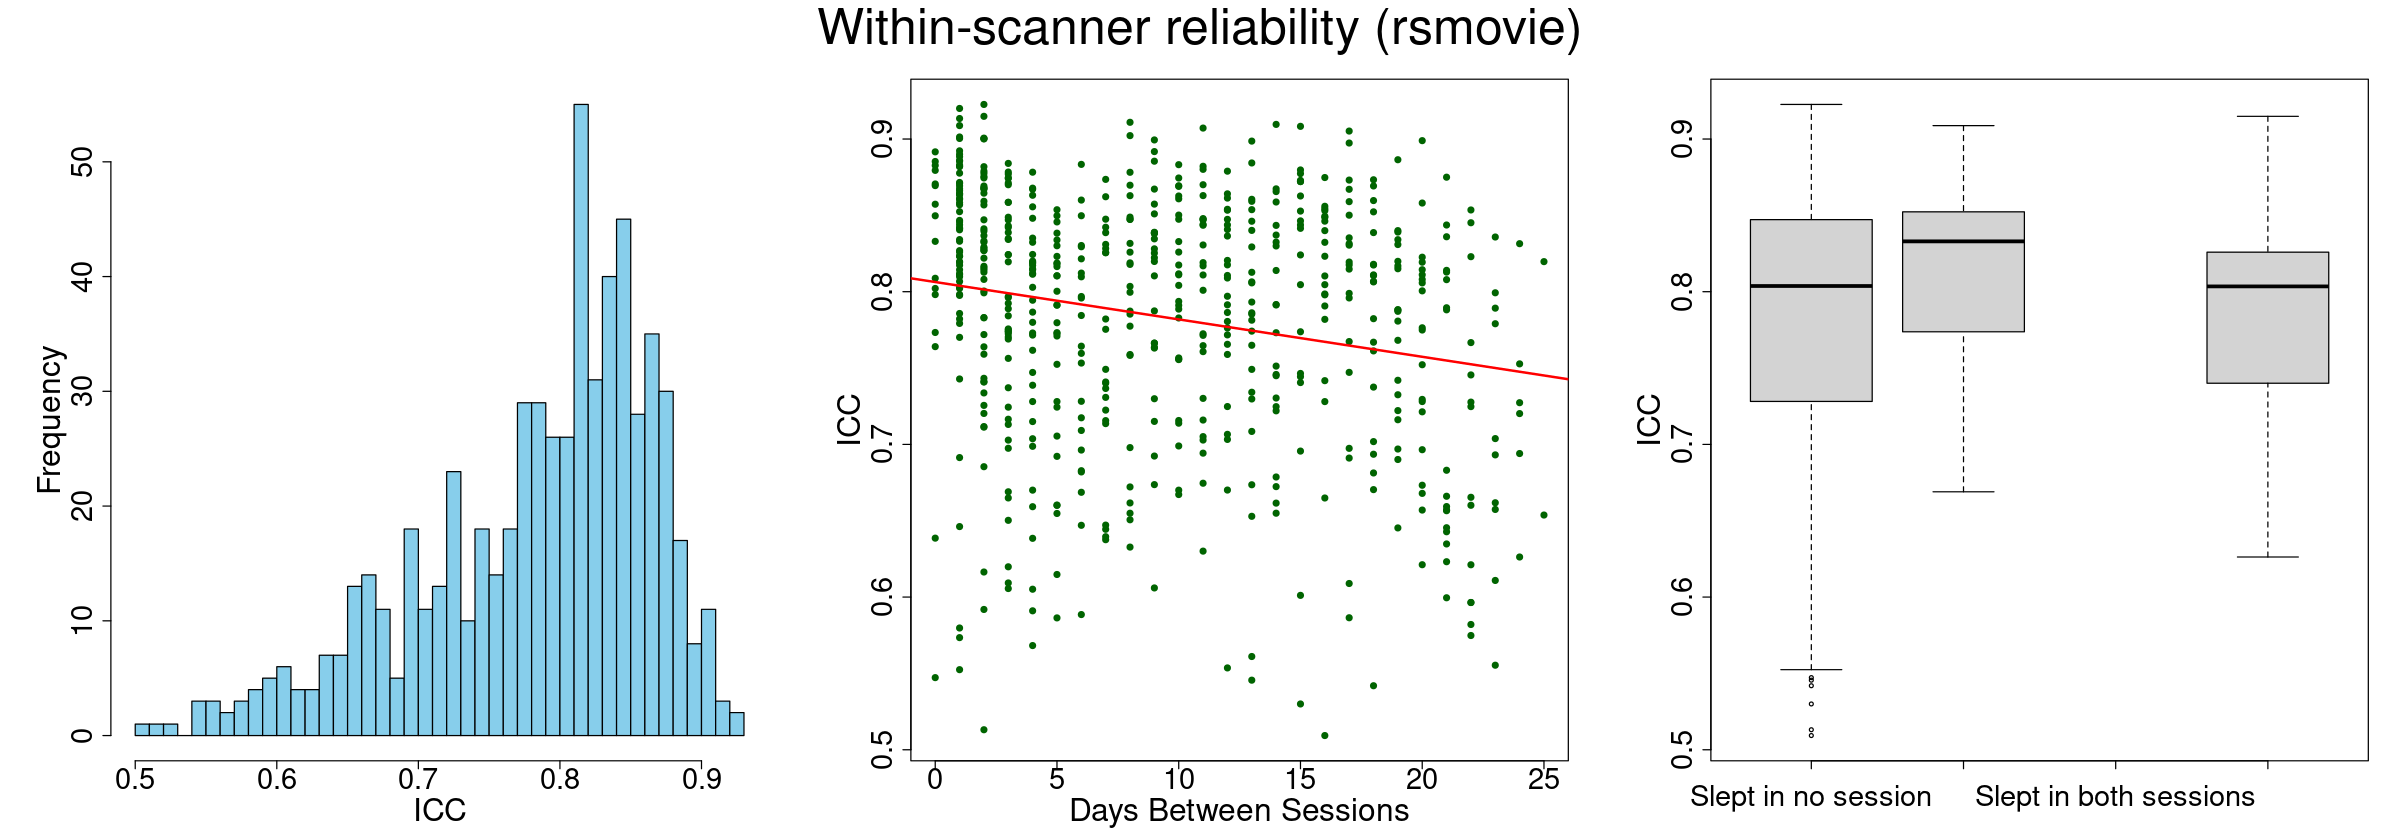

In [117]:
icc_intra_rsmovie <- icc_combined[icc_combined$variability_type == "within-scanner" & icc_combined$meas == meas & icc_combined$task == "rsmovie", ]

# Sleep influence on ICC
icc_intra_rsmovie$slept_factor <- factor(
    ifelse(is.na(icc_intra_rsmovie$slept), -1, icc_intra_rsmovie$slept),
    levels = c(0, 1, 2, -1),
    labels = c("Slept in no session", "Slept in one session", "Slept in both sessions", "Unknown")
)

# Make the plot wider by increasing the width of the plotting window and font sizes
options(repr.plot.width = 20, repr.plot.height = 7)
par(mfrow = c(1, 3), cex.axis = 2.2, cex.lab = 2.4, cex.main = 2.5, cex.sub = 2.2, mar = c(5, 7, 5, 2))  # Further increase font sizes
hist(
    icc_intra_rsmovie$ICC,
    breaks = 30,
    main = "",
    xlab = "ICC",
    col = "skyblue",
    cex.axis = 2.2,
    cex.lab = 2.4,
    cex.main = 2.5
)
plot(
    icc_intra_rsmovie$days_diff, icc_intra_rsmovie$ICC,
    xlab = "Days Between Sessions",
    ylab = "ICC",
    main = "",
    pch = 19, col = "darkgreen",
    cex.axis = 2.2,
    cex.lab = 2.4,
    cex.main = 2.5
)
abline(lm(ICC ~ days_diff, data = icc_intra_rsmovie), col = "red", lwd = 2)

boxplot(
    ICC ~ slept_factor, data = icc_intra_rsmovie,
    xlab = "",
    ylab = "ICC",
    cex.axis = 2.2,
    cex.lab = 2.4,
    cex.main = 2.5,
    xaxt = "n" # suppress default x-axis
)
axis(
    side = 1,
    at = 1:4,
    labels = levels(icc_intra_rsmovie$slept_factor),
    cex.axis = 2.2,
    padj = 0.8 # move labels lower
)
mtext("Within-scanner reliability (rsmovie)", outer = TRUE, line = -3, cex = 2.5)
par(mfrow = c(1, 1))  # Reset plotting area

In [118]:
icc_intra_rest <- icc_combined[icc_combined$variability_type == "within-scanner" & icc_combined$meas == meas & icc_combined$task == "rest", ]
# Set up a 3x3 plotting area for all three scanners
options(repr.plot.width = 27, repr.plot.height = 15)
par(mfrow = c(3, 3), cex.axis = 2, cex.lab = 2.2, cex.main = 2.5, cex.sub = 2, mar = c(5, 7, 5, 2))  # Increase font sizes and margins

# Determine global x-axis limits for ICC
icc_range <- range(icc_intra_rest$ICC, na.rm = TRUE)

icc_intra_rest$slept_factor <- factor(
    ifelse(is.na(icc_intra_rest$slept), -1, icc_intra_rest$slept),
    levels = c(0, 1, 2, -1),
    labels = c("Slept in no session", "Slept in one session", "Slept in both sessions", "Unknown")
)

for (scanner in c("vida", "vidafit", "prisma")) {
    icc_intra_rest_scanner <- icc_intra_rest[icc_intra_rest$scanner == scanner, ]
    mean_icc <- mean(icc_intra_rest_scanner$ICC, na.rm = TRUE)
    quantiles <- quantile(icc_intra_rest_scanner$ICC, probs = c(0.25, 0.5, 0.75), na.rm = TRUE)   
    # Histogram with fixed xlim
    hist(
        icc_intra_rest_scanner$ICC,
        breaks = 30,
        xlab = "ICC",
        main = '',
        col = "skyblue",
        cex.axis = 2,
        cex.lab = 2.2,
        xlim = icc_range
    )
    mtext(scanner, side = 2, line = 3, cex = 2.2, las = 0)
    # Scatter plot: ICC vs days_diff
    plot(
        icc_intra_rest_scanner$days_diff, icc_intra_rest_scanner$ICC,
        xlab = "Days Between Sessions",
        ylab = "ICC",
        pch = 19, col = "darkgreen",
        cex.axis = 2,
        cex.lab = 2.2
    )
    abline(lm(ICC ~ days_diff, data = icc_intra_rest_scanner), col = "red", lwd = 2)

    # Sleep influence on ICC
    boxplot(
        ICC ~ slept_factor, data = icc_intra_rest_scanner,
        xlab = "",
        ylab = "ICC",
        cex.axis = 2.2,
        cex.lab = 2.4,
        cex.main = 2.5,
        xaxt = "n" # suppress default x-axis
    )
    axis(
        side = 1,
        at = 1:3,
        labels = levels(icc_intra_rest_scanner$slept_factor),
        cex.axis = 2.2,
        padj = 0.8 # move labels lower
    )
    mtext("Within-scanner reliability (rest)", outer = TRUE, line = -3, cex = 2.5)
}
par(mfrow = c(1, 1))  # Reset plotting area


ERROR: Error in axis(side = 1, at = 1:3, labels = levels(icc_intra_rest_scanner$slept_factor), : 'at' and 'labels' lengths differ, 3 != 4


In [119]:
# Perform Wilcoxon signed-rank test to compare ICC distribution with sparseinversecovariance versus correlation for each variability type
# ICC distribution are clearly not normal, so we use this non-parametric test instead of a t-test
icc_significance <- df_plot %>%
    group_by(variability_plotname) %>%
    summarise(
        p_value = wilcox.test(ICC ~ meas, data = cur_data())$p.value
    ) %>%
    mutate(
        significance = case_when(
            p_value < 0.001 ~ "***",
            p_value < 0.01 ~ "**",
            p_value < 0.05 ~ "*",
            TRUE ~ "ns"
        )
    )

print(icc_significance)

# A tibble: 6 × 3
  variability_plotname               p_value significance
  <fct>                                <dbl> <chr>       
1 Within-scanner (rsmovie, prisma) 2.27e-116 ***         
2 Within-scanner (rest, vida)      3.85e- 10 ***         
3 Within-scanner (rest, vidafit)   1.49e-  7 ***         
4 Within-scanner (rest, prisma)    1.56e-  7 ***         
5 Between-scanner (rest)           1.25e- 42 ***         
6 Between-paradigm (prisma)        4.12e- 67 ***         


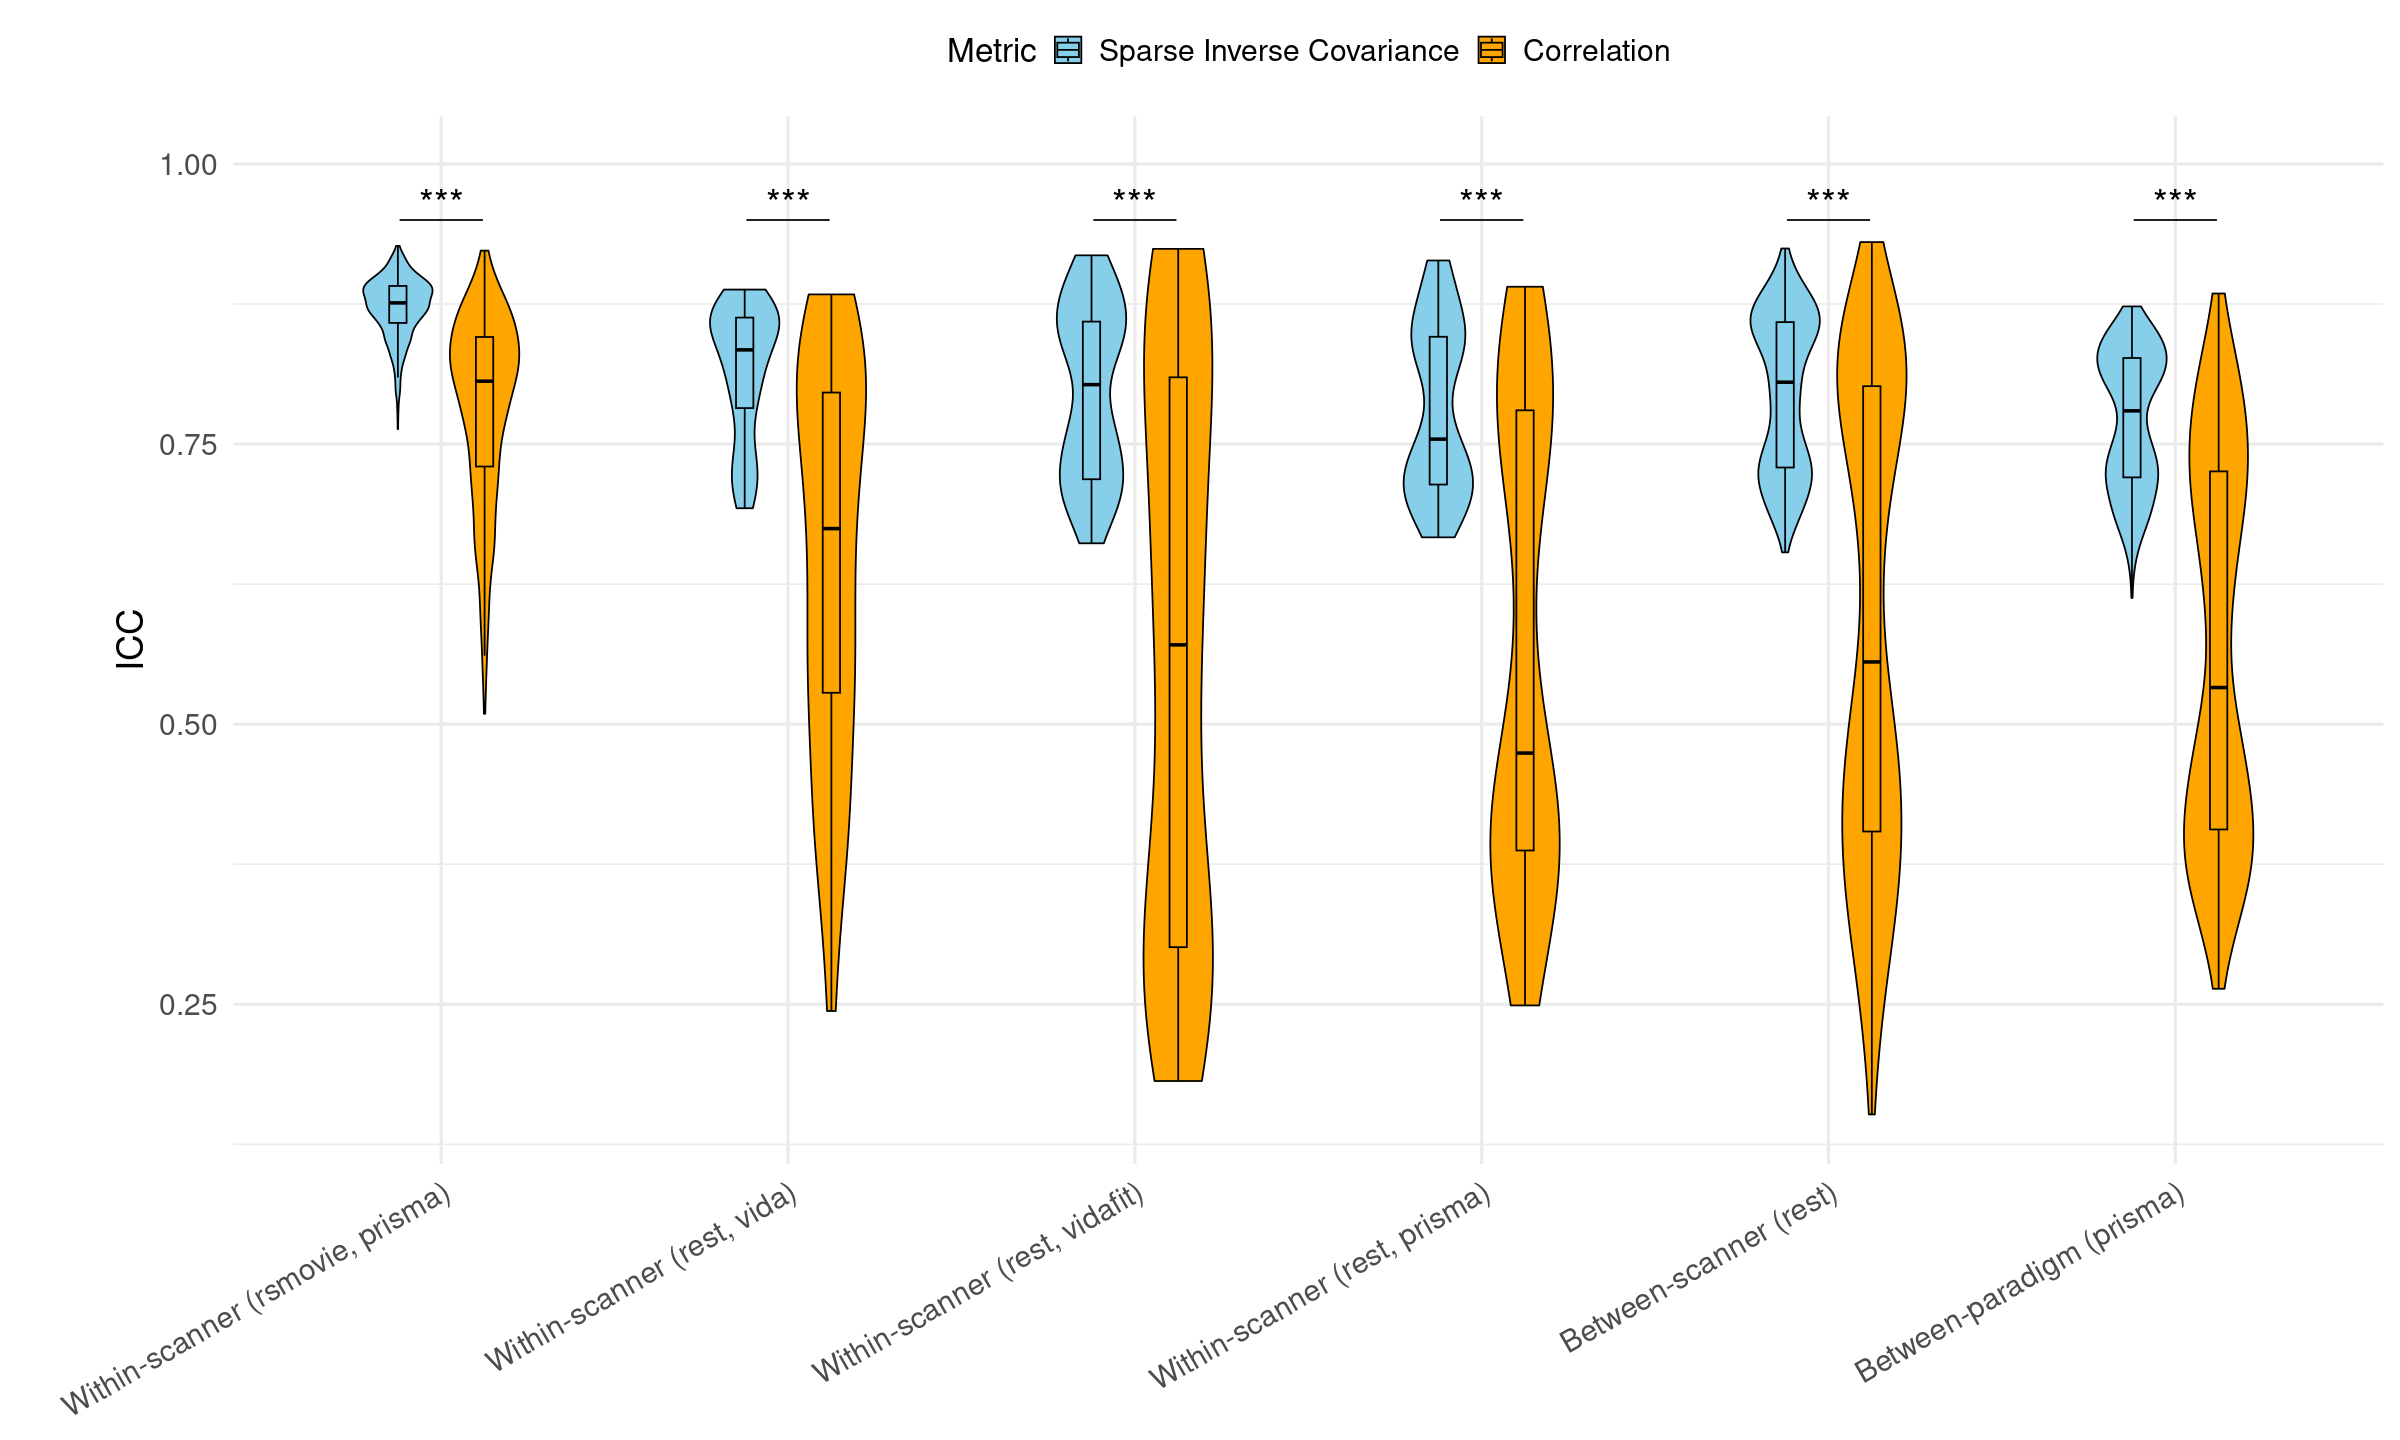

In [157]:
# Reduce the height of the plot by setting the output height (for Jupyter)
options(repr.plot.height = 12)
options(repr.plot.width = 20)

library(ggplot2)
library(dplyr)

# Filter only the bootstrap/permutation ICCs (exclude summary statistics)
df_plot <- icc_combined %>%
    filter(is.na(summary_statistic)) %>%
    mutate(
        variability_plotname = case_when(
            variability_type == "within-scanner" & task == "rsmovie" ~ "Within-scanner (rsmovie, prisma)",
            variability_type == "within-scanner" & task == "rest" & scanner == "prisma" ~ "Within-scanner (rest, prisma)",
            variability_type == "within-scanner" & task == "rest" & scanner == "vida" ~ "Within-scanner (rest, vida)",
            variability_type == "within-scanner" & task == "rest" & scanner == "vidafit" ~ "Within-scanner (rest, vidafit)",
            variability_type == "between-scanner" ~ "Between-scanner (rest)",
            variability_type == "between-paradigm" ~ "Between-paradigm (prisma)",
            TRUE ~ NA_character_
        )
    )

# Set factor order for plot
df_plot$meas <- factor(df_plot$meas, levels = c("sparseinversecovariance", "correlation"), labels = c("Sparse Inverse Covariance", "Correlation"))
df_plot$variability_plotname <- factor(df_plot$variability_plotname, levels = c(
    "Within-scanner (rsmovie, prisma)",
    "Within-scanner (rest, vida)",
    "Within-scanner (rest, vidafit)",
    "Within-scanner (rest, prisma)",    
    "Between-scanner (rest)",
    "Between-paradigm (prisma)"
))

# Merge significance data with the plot data
df_plot <- df_plot %>%
    left_join(icc_significance, by = "variability_plotname")

# Plot with increased font size and significance annotations
ggplot(df_plot, aes(x = variability_plotname, y = ICC, fill = meas)) +
    geom_violin(trim = TRUE, position = position_dodge(width = 0.5), color = "black", width = 0.4, scale="width") +
    geom_boxplot(aes(fill = meas), width = 0.1, position = position_dodge(width = 0.5), outlier.shape = NA, color = "black") +
    geom_segment(
        data = icc_significance,
        aes(
            x = as.numeric(variability_plotname) - 0.12,
            xend = as.numeric(variability_plotname) + 0.12 ,
            y = 0.95,
            yend = 0.95
        ),
        inherit.aes = FALSE,
        size = 0.5,
        color = "black"
    ) +
    geom_text(
        data = icc_significance,
        aes(
            x = as.numeric(variability_plotname),
            y = 0.94,
            label = significance
        ),
        inherit.aes = FALSE,
        size = 8,
        vjust = -0.5,
    ) +
    theme_minimal(base_size = 20) +
    labs(x = NULL, y = "ICC", fill = "Metric") +
    theme(
        axis.text.x = element_text(angle = 30, hjust = 1, size = 18),
        axis.text.y = element_text(size = 18),
        axis.title.y = element_text(size = 22),
        plot.title = element_text(size = 24, face = "bold"),
        legend.position = "top",
        legend.text = element_text(size = 18),  # Increase legend text size
        legend.title = element_text(size = 20), # Increase legend title size
        plot.margin = margin(t = 10, r = 10, b = 10, l = 70)
    ) +
    scale_fill_manual(values = c("skyblue", "orange")) +
    ylim(0.15, 1.0)

# Save the plot to a file
py_run_string(" 
entities = {
    'experiment': 'scannereffects',
    'extension': '.png',
    'datatype': 'figures',
    'suffix': 'bold',
    'desc': 'icccomparative',
}
entities.update(entities_base)
entities['measure'] = None
save_path = save_layout.build_path(entities, validate=False)
#")
ggsave(filename = py$save_path, width = 12, height = 8, dpi = 300)


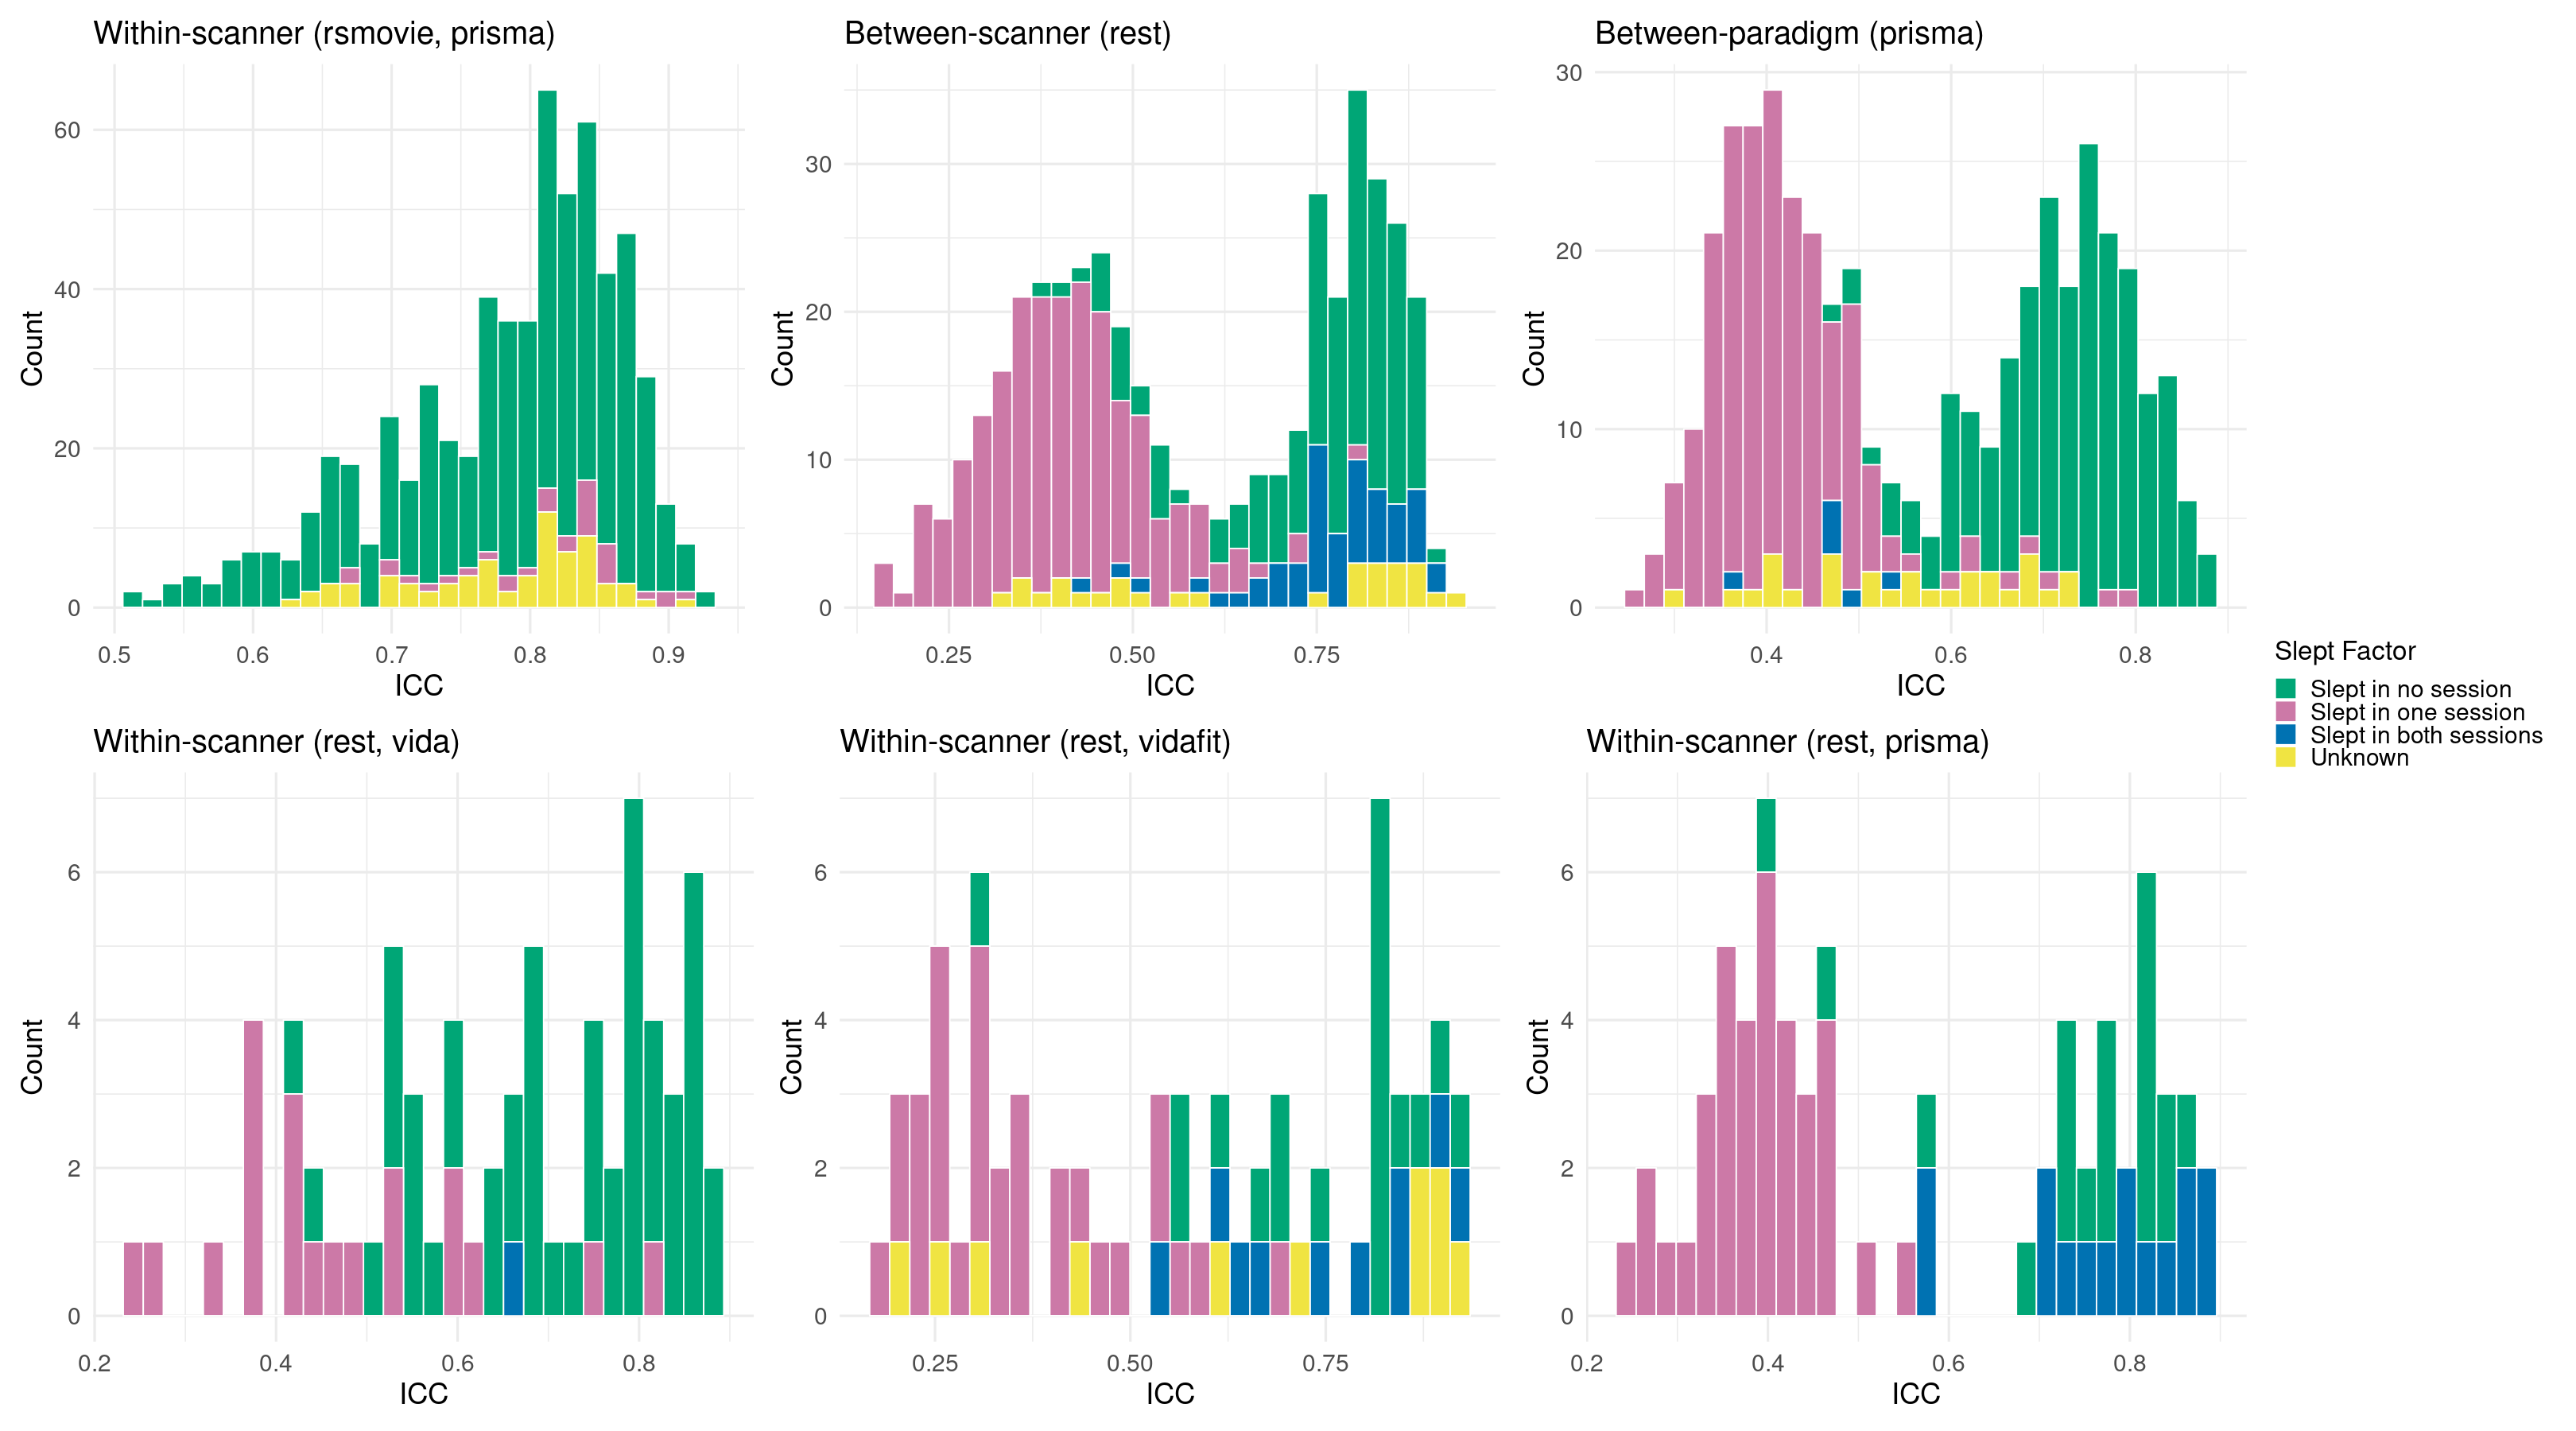

In [158]:
library(patchwork)

# Create individual plots
options(repr.plot.width = 27, repr.plot.height = 15)
plot_rsmovie <- ggplot(data = icc_intra_rsmovie, aes(x = ICC, fill = slept_factor)) +
    geom_histogram(color = 'white', bins = 30, position = "stack") +
    labs(
        x = "ICC",
        y = "Count",
        fill = "Slept Factor",
        title = "Within-scanner (rsmovie, prisma)"
    ) +
    theme_minimal(base_size = 20) +
    theme(
        axis.text.x = element_text(size = 18),
        axis.text.y = element_text(size = 18),
        axis.title.x = element_text(size = 22),
        axis.title.y = element_text(size = 22),
        legend.text = element_text(size = 18),
        legend.title = element_text(size = 20),
        legend.position = "none" 
    ) +
    scale_fill_manual(values = c("#00A676", "#CC79A7", "#F0E442"))

plot_between <- ggplot(data = icc_between, aes(x = ICC, fill = slept_factor)) +
    geom_histogram(color = 'white', bins = 30, position = "stack") +
    labs(
        x = "ICC",
        y = "Count",
        fill = "Slept Factor",
        title = "Between-scanner (rest)"
    ) +
    theme_minimal(base_size = 20) +
    theme(
        axis.text.x = element_text(size = 18),
        axis.text.y = element_text(size = 18),
        axis.title.x = element_text(size = 22),
        axis.title.y = element_text(size = 22),
        legend.text = element_text(size = 18),
        legend.title = element_text(size = 20),
        legend.position = "none" 
    ) +
    scale_fill_manual(values = c("#00A676", "#CC79A7", "#0072B2", "#F0E442"))

plot_paradigm <- ggplot(data = icc_paradigm, aes(x = ICC, fill = slept_factor)) +
    geom_histogram(color = 'white', bins = 30, position = "stack") +
    labs(
        x = "ICC",
        y = "Count",
        fill = "Slept Factor",
        title = "Between-paradigm (prisma)"
    ) +
    theme_minimal(base_size = 20) +
    theme(
        axis.text.x = element_text(size = 18),
        axis.text.y = element_text(size = 18),
        axis.title.x = element_text(size = 22),
        axis.title.y = element_text(size = 22),
        legend.text = element_text(size = 18),
        legend.title = element_text(size = 20),
        legend.position = "right" 
    ) +
    scale_fill_manual(values = c("#00A676", "#CC79A7", "#0072B2", "#F0E442"))

# Create plots for each scanner
plots_scanners <- lapply(c("vida", "vidafit", "prisma"), function(scanner) {
    icc_intra_rest_scanner <- icc_intra_rest[icc_intra_rest$scanner == scanner, ]
    title <- switch(
        scanner,
        "vida" = "Within-scanner (rest, vida)",
        "vidafit" = "Within-scanner (rest, vidafit)",
        "prisma" = "Within-scanner (rest, prisma)"
    )
    ggplot(data = icc_intra_rest_scanner, aes(x = ICC, fill = slept_factor)) +
        geom_histogram(color = 'white', bins = 30, position = "stack") +
        labs(
            x = "ICC",
            y = "Count",
            fill = "Slept Factor",
            title = title
        ) +
        theme_minimal(base_size = 20) +
        theme(
            axis.text.x = element_text(size = 18),
            axis.text.y = element_text(size = 18),
            axis.title.x = element_text(size = 22),
            axis.title.y = element_text(size = 22),
            legend.text = element_text(size = 18),
            legend.title = element_text(size = 20),
            legend.position = "none"  # Hide legend for individual scanner plots
        ) +
        scale_fill_manual(values = c("#00A676", "#CC79A7", "#0072B2", "#F0E442"))
})

# Combine all plots into a single figure with one legend
combined_plot <- (plot_rsmovie | plot_between | plot_paradigm) / wrap_plots(plots_scanners, ncol = 3) +
    plot_layout(guides = "collect") 

# Save the plot to a file
py_run_string(" 
entities = {
    'experiment': 'scannereffects',
    'extension': '.png',
    'datatype': 'figures',
    'suffix': 'bold',
    'desc': 'iccVSsleep',
}
entities.update(entities_base)
save_path = save_layout.build_path(entities, validate=False)
#")
ggsave(filename = py$save_path, width = 12, height = 8, dpi = 300)

# Display the combined plot
print(combined_plot)